In [ ]:


    # ============================================================
    # 4. RANGO LÍNEA SAE
    # ============================================================

    df_base = df_base.withColumn(
        "RANGO_linea_sae",

        F.when(
            F.col("LINEA_SAE") < 5000,
            "01. [0 - 5000>"
        )

        .when(
            F.col("LINEA_SAE") < 10000,
            "02. [5000 - 10000>"
        )

        .when(
            F.col("LINEA_SAE") < 15000,
            "03. [10000 - 15000>"
        )

        .when(
            F.col("LINEA_SAE") < 20000,
            "04. [15000 - 20000>"
        )

        .when(
            F.col("LINEA_SAE") < 30000,
            "05. [20000 - 30000>"
        )

        .otherwise(
            "06. [30000>"
        )
    )


    # ============================================================
    # 5. RANGO TASA
    # ============================================================

    df_base = df_base.withColumn(
        "RANGO_TASA",

        F.when(
            F.col("TEA").isNull(),
            "Sin tasa"
        )

        .when(
            F.col("TEA") < 0.10,
            "01. < 10%"
        )

        .when(
            F.col("TEA") < 0.20,
            "02. 10% - 20%"
        )

        .when(
            F.col("TEA") < 0.30,
            "03. 20% - 30%"
        )

        .when(
            F.col("TEA") < 0.40,
            "04. 30% - 40%"
        )

        .when(
            F.col("TEA") < 0.50,
            "05. 40% - 50%"
        )

        .when(
            F.col("TEA") < 0.60,
            "06. 50% - 60%"
        )

        .when(
            F.col("TEA") < 0.70,
            "07. 60% - 70%"
        )

        .when(
            F.col("TEA") < 0.80,
            "08. 70% - 80%"
        )

        .when(
            F.col("TEA") <= 1.00,
            "09. 80% - 100%"
        )

        .otherwise(
            "10. > 100%"
        )
    )



In [ ]:
['2026-07 SAE', '2026-06 CD', '2026-05 CD', '2026-07 SAR', '2026-05 SAR', '2026-03 SAE', '2026-04 CD', '2026-05 SAE', '2026-04 SAR', '2026-06 SAE', '2026-08 CD', '2026-04 SAE', '2026-09 SAE', '2026-08 SAR', '2026-03 SAR', '2026-06 SAR', '2026-08 SAE', '2026-09 SAR']


query = f"""
    select 
        cod as Codigo_Paleta,
        [NIVEL 2] as estado,
        [NIVEL 3] as sub_estado,
        [NIVEL 4] as descripcion,
        peso
    FROM ODIN.dbo.tTipologia_Diners_TC
    where  LEFT(cod,2)='E0' or LEFT(cod,2)='H0' or [NIVEL 2]='NO CONTACTO' or cod='CALLBK'
"""
df_tipologia=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_tipologia=df_tipologia.dropDuplicates(['Codigo_Paleta'])


    fecha_mes_base='2026-09-01'
    servidor_01=76
    tipi_cond1='SAE'
    tipi_cond2='SAR'
    tipi_cond3='AGENDA'
    tb_tipolofia='tTipologia_Cencosud_PPFF'
    tipi_cod='Codigo'
    tipi_resp_cod='R0'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO GESTIONADO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroCenco_Sae'
    tnum_dni='CODDOC'
    tlista_generada='borrar_prestamo_cencosud'
    get_base=since_base_maestra_cencosud_ppff


query = f"""
    select 
        Dni as vendor_lead_code,
        Nombre_Campana,
        Fecha_Hora_Llamada,
        segundos,
        Fecha_Llamada,
        Codigo_Paleta,
        [NIVEL 2] as estado,
        [NIVEL 3] as sub_estado,
        [NIVEL 4] as descripcion,
        peso,        
        case
            when Nombre_Campana ='2026-09 DINERS TC' then '2026-09-01'
            when Nombre_Campana ='2026-08 DINERS TC' then '2026-08-01'
            when Nombre_Campana ='2026-07 DINERS TC SEG' then '2026-07-01'
            when Nombre_Campana ='2026-07 DINERS TC' then '2026-07-01'
            when Nombre_Campana ='2026-06 DINERS TC' then '2026-06-01'
            when Nombre_Campana ='2026-05 DINERS TC' then '2026-05-01'
        end as mes
    FROM SAMANTHA.dbo.tmp_llamadas_mes
    where fecha_llamada>='2026-05-01'
    and Nombre_Campana in(
        '2026-08 DINERS TC', '2026-05 DINERS TC', '2026-07 DINERS TC', '2026-09 DINERS TC', '2026-06 DINERS TC', '2026-07 DINERS TC SEG')
    and  LEFT(cod,2)='E0' or LEFT(cod,2)='H0' or [NIVEL 2]='NO CONTACTO' or cod='CALLBK'

"""
df_llamadas_diners_tc=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)




fecha_ref = '2026-04-01'

lla_nombre_campana1='SAE'
lla_nombre_campana2='SAR'
lla_nombre_campana3='AGENDA'
venta_campana='Efectiva'
tb_tipologia='tTipologia_Cencosud_PPFF'
dni_tnumero='CODDOC'
cod_letra='BR'
tb_tnumero='tNumeroCenco_Sae'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_ref}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE (nombre_campana LIKE '%{lla_nombre_campana1}' | nombre_campana LIKE '%{lla_nombre_campana2}' | nombre_campana LIKE '%{lla_nombre_campana3}')
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_ref}')
AND fecha_llamada <  '{fecha_ref}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

### funciones

In [1]:
def analizar_antiguedad(df, producto):

    # ============================================================
    # 1. FILTRAR Y PREPARAR
    # ============================================================

    datos = df.loc[
        df["producto"] == producto
    ].copy()

    datos["mes"] = pd.to_datetime(
        datos["mes"],
        errors="coerce"
    )

    datos["cantidad"] = pd.to_numeric(
        datos["cantidad"],
        errors="coerce"
    ).fillna(0)

    datos["diferencia"] = pd.to_numeric(
        datos["diferencia"],
        errors="coerce"
    )

    datos = datos.dropna(
        subset=["mes", "diferencia"]
    )

    datos["diferencia"] = datos["diferencia"].astype(int)


    # ============================================================
    # 2. CREAR ANTIGÜEDAD
    # ============================================================

    datos["antiguedad"] = datos["diferencia"].apply(
        lambda x:
            "0 - Nuevo" if x == 0
            else "1 - Hace 1 mes" if x == 1
            else f"{x} - Hace {x} meses"
    )


    # ============================================================
    # 3. AGRUPAR
    # ============================================================

    resumen = (
        datos
        .groupby(
            ["mes", "diferencia", "antiguedad"],
            as_index=False
        )["cantidad"]
        .sum()
    )

    orden = (
        resumen
        .sort_values("diferencia")["antiguedad"]
        .drop_duplicates()
        .tolist()
    )


    # ============================================================
    # 4. TABLA PIVOT
    # ============================================================

    tabla_cantidad = (
        resumen
        .pivot(
            index="mes",
            columns="antiguedad",
            values="cantidad"
        )
        .fillna(0)
        .reindex(columns=orden, fill_value=0)
        .sort_index()
    )

    total_base = tabla_cantidad.sum(axis=1)


    # ============================================================
    # 5. PORCENTAJES
    # ============================================================

    tabla_porcentaje = (
        tabla_cantidad
        .div(total_base, axis=0)
        .mul(100)
    )

    tabla_porcentaje["Total base"] = total_base


    # ============================================================
    # 6. GRÁFICO
    # ============================================================

    ax = tabla_porcentaje[orden].plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7),
        width=0.80
    )


    # Porcentajes dentro de las barras
    for contenedor in ax.containers:

        etiquetas = [
            f"{barra.get_height():.1f}%"
            if barra.get_height() >= 2
            else ""
            for barra in contenedor
        ]

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=8
        )


    # Total encima de cada barra
    for i, total in enumerate(total_base):

        ax.text(
            i,
            101.5,
            f"{total:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


    # ============================================================
    # 7. FORMATO
    # ============================================================

    ax.set_title(
        f"{producto}\n"
        "Distribución porcentual según antigüedad",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel("Mes de recepción")
    ax.set_ylabel("Participación (%)")

    ax.set_xticklabels(
        [
            fecha.strftime("%b-%Y")
            for fecha in tabla_porcentaje.index
        ],
        rotation=45
    )

    ax.set_ylim(0, 108)

    ax.legend(
        title="Antigüedad del registro",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


    # ============================================================
    # 8. TABLA FINAL
    # ============================================================

    tabla_final = tabla_porcentaje.copy()

    for columna in orden:
        tabla_final[columna] = (
            tabla_final[columna]
            .map(lambda x: f"{x:.2f}%")
        )

    tabla_final["Total base"] = (
        tabla_final["Total base"]
        .astype(int)
    )

    display(tabla_final)


    # IMPORTANTE:
    # devolver tablas para poder utilizarlas después
    return tabla_final, tabla_cantidad

def analizar_propension(df, producto):

    # ============================================================
    # 1. ORDEN SEGÚN PRODUCTO
    # ============================================================

    orden_por_producto = {
        "EC Cliente": ["ALTO","MEDIO","BAJO","SIN PROPENSION"],
        "Reenganche EC": ["1","2","3","4","5","6","7","8","9","10","SIN PROPENSION"]
    }

    orden = orden_por_producto[producto]


    # ============================================================
    # 2. FILTRAR Y PREPARAR
    # ============================================================

    datos = (
        df.loc[df["producto"] == producto]
        .copy()
    )

    datos["mes"] = pd.to_datetime(
        datos["mes"],
        errors="coerce"
    )

    datos["cantidad"] = pd.to_numeric(
        datos["cantidad"],
        errors="coerce"
    ).fillna(0)

    datos["PROPENSION"] = (
        datos["PROPENSION"]
        .fillna("SIN PROPENSION")
        .astype(str)
        .str.upper()
        .str.strip()
    )


    # ============================================================
    # 3. TABLA DE CANTIDADES
    # ============================================================

    tabla_cantidad = (
        datos
        .groupby(["mes", "PROPENSION"])["cantidad"]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=orden, fill_value=0)
        .sort_index()
    )

    total_base = tabla_cantidad.sum(axis=1)


    # ============================================================
    # 4. TABLA PORCENTUAL
    # ============================================================

    tabla_pct = (
        tabla_cantidad
        .div(total_base, axis=0)
        .mul(100)
    )

    tabla_pct["Total Base"] = total_base


    # ============================================================
    # 5. GRÁFICO
    # ============================================================

    ax = tabla_pct[orden].plot(
        kind="bar",
        stacked=True,
        figsize=(14, 7),
        width=0.80
    )

    # Porcentajes dentro de las barras
    for contenedor in ax.containers:

        etiquetas = [
            f"{barra.get_height():.1f}%"
            if barra.get_height() >= 3
            else ""
            for barra in contenedor
        ]

        ax.bar_label(
            contenedor,
            labels=etiquetas,
            label_type="center",
            fontsize=8
        )


    # Total encima de cada barra
    for i, total in enumerate(total_base):

        ax.text(
            i,
            101.5,
            f"{total:,.0f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )


    # ============================================================
    # 6. FORMATO
    # ============================================================

    ax.set_title(
        f"{producto}\n"
        "Distribución porcentual por propensión",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_ylabel("Participación (%)")
    ax.set_xlabel("Mes recepción")

    ax.set_xticklabels(
        [
            fecha.strftime("%b-%Y")
            for fecha in tabla_pct.index
        ],
        rotation=45
    )

    ax.set_ylim(0, 108)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.legend(
        title="Propensión",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


    # ============================================================
    # 7. TABLA FINAL
    # ============================================================

    tabla_final = tabla_pct.copy()

    for columna in orden:
        tabla_final[columna] = (
            tabla_final[columna]
            .map(lambda x: f"{x:.2f}%")
        )

    tabla_final["Total Base"] = (
        tabla_final["Total Base"]
        .astype(int)
    )

    display(tabla_final)

    return tabla_final

def analizar_evolucion_propension(df,producto,anio=2026):
    # ============================================================
    # 1. PROPENSIONES SEGÚN PRODUCTO
    # ============================================================

    propensiones_por_producto = {

        "EC Cliente": [
            "ALTO",
            "MEDIO",
            "BAJO"
        ],

        "Reenganche EC": [
            "1",
            "2",
            "3",
            "4"
        ]
    }

    propensiones = propensiones_por_producto[producto]


    # ============================================================
    # 2. FILTRAR PRODUCTO
    # ============================================================

    datos = (
        df.loc[
            df["producto"] == producto
        ]
        .copy()
    )


    # ============================================================
    # 3. TIPOS DE DATOS
    # ============================================================

    datos["mes"] = pd.to_datetime(
        datos["mes"],
        errors="coerce"
    )

    datos["PROPENSION"] = (
        datos["PROPENSION"]
        .fillna("SIN PROPENSION")
        .astype(str)
        .str.upper()
        .str.strip()
    )

    columnas_numericas = [
        "tea_sum",
        "tea_count",
        "linea_sae_sum",
        "linea_sae_count"
    ]

    for col in columnas_numericas:

        datos[col] = pd.to_numeric(
            datos[col],
            errors="coerce"
        ).fillna(0)


    # ============================================================
    # 4. FILTRAR AÑO + PROPENSIONES
    # ============================================================

    datos = datos[
        (datos["mes"].dt.year == anio)
        &
        (datos["PROPENSION"].isin(propensiones))
    ].copy()


    # ============================================================
    # 5. RESUMEN MES + PROPENSIÓN
    # ============================================================

    resumen = (
        datos
        .groupby(
            ["mes", "PROPENSION"],
            as_index=False
        )
        .agg(
            tea_sum=("tea_sum", "sum"),
            tea_count=("tea_count", "sum"),
            linea_sae_sum=("linea_sae_sum", "sum"),
            linea_sae_count=("linea_sae_count", "sum")
        )
    )


    # ============================================================
    # 6. INDICADORES
    # ============================================================

    resumen["LINEA_SAE_PROMEDIO"] = (
        resumen["linea_sae_sum"]
        /
        resumen["linea_sae_count"]
    )

    resumen["TASA"] = (
        resumen["tea_sum"]
        /
        resumen["tea_count"]
        * 100
    )


    resumen = resumen[
        (resumen["tea_count"] > 0)
        &
        (resumen["linea_sae_count"] > 0)
    ].copy()


    # ============================================================
    # 7. ORDEN
    # ============================================================

    resumen["PROPENSION"] = pd.Categorical(
        resumen["PROPENSION"],
        categories=propensiones,
        ordered=True
    )

    resumen = resumen.sort_values(
        ["PROPENSION", "mes"]
    )


    # ============================================================
    # 8. PALETA
    # ============================================================

    colores = [
        "#1F77B4",   # azul fuerte
        "#5DA5DA",   # azul medio
        "#F28E2B",   # naranja
        "#FFBE7D"    # naranja claro
    ]


    # ============================================================
    # 9. GRÁFICO 1 - LÍNEA SAE
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 6)
    )

    for i, prop in enumerate(propensiones):

        temp = resumen[
            resumen["PROPENSION"] == prop
        ].sort_values("mes")

        ax.plot(
            temp["mes"],
            temp["LINEA_SAE_PROMEDIO"],
            marker="o",
            linewidth=2,
            markersize=7,
            color=colores[i],
            label=f"Propensión {prop}"
        )


        # Etiqueta último mes
        if not temp.empty:

            ultimo = temp.iloc[-1]

            ax.annotate(
                f"{ultimo['LINEA_SAE_PROMEDIO']:,.0f}",
                (
                    ultimo["mes"],
                    ultimo["LINEA_SAE_PROMEDIO"]
                ),
                xytext=(7, 0),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                va="center",
                color=colores[i]
            )


    ax.set_title(
        f"{producto}\n"
        f"Evolución mensual de Línea SAE promedio - {anio}",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel("Mes")
    ax.set_ylabel("Línea SAE promedio (S/)")

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Propensión",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


    # ============================================================
    # 10. GRÁFICO 2 - TASA
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 6)
    )

    for i, prop in enumerate(propensiones):

        temp = resumen[
            resumen["PROPENSION"] == prop
        ].sort_values("mes")

        ax.plot(
            temp["mes"],
            temp["TASA"],
            marker="o",
            linewidth=2,
            markersize=7,
            color=colores[i],
            label=f"Propensión {prop}"
        )


        # Etiqueta último mes
        if not temp.empty:

            ultimo = temp.iloc[-1]

            ax.annotate(
                f"{ultimo['TASA']:.1f}%",
                (
                    ultimo["mes"],
                    ultimo["TASA"]
                ),
                xytext=(7, 0),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold",
                va="center",
                color=colores[i]
            )


    ax.set_title(
        f"{producto}\n"
        f"Evolución mensual de Tasa - {anio}",
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel("Mes")

    ax.set_ylabel(
        "Tasa (%)  → menor es mejor"
    )

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    ax.legend(
        title="Propensión",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


    # ============================================================
    # 11. TABLA FINAL
    # ============================================================

    tabla_final = resumen[
        [
            "mes",
            "PROPENSION",
            "LINEA_SAE_PROMEDIO",
            "TASA",
            "linea_sae_count"
        ]
    ].copy()


    tabla_final = tabla_final.rename(
        columns={
            "linea_sae_count": "REGISTROS"
        }
    )


    tabla_final["LINEA_SAE_PROMEDIO"] = (
        tabla_final["LINEA_SAE_PROMEDIO"]
        .round(2)
    )

    tabla_final["TASA"] = (
        tabla_final["TASA"]
        .round(2)
    )

    tabla_final["REGISTROS"] = (
        tabla_final["REGISTROS"]
        .astype(int)
    )


    display(tabla_final)

    return tabla_final




def analizar_oportunidad_2_meses(df,producto,meses=("2026-08", "2026-09")):

    # ============================================================
    # 1. VALIDAR MÁXIMO 2 MESES
    # ============================================================

    if len(meses) != 2:
        raise ValueError("Debes indicar exactamente 2 meses. Ejemplo: ('2026-08', '2026-09')")


    # ============================================================
    # 2. ORDEN SEGÚN PRODUCTO
    # ============================================================

    orden_por_producto = {

        "EC Cliente": [
            "ALTO",
            "MEDIO",
            "BAJO",
            "SIN PROPENSION"
        ],

        "Reenganche EC": [
            "1",
            "2",
            "3",
            "4",
            "5",
            "6",
            "7",
            "8",
            "9",
            "10",
            "SIN PROPENSION"
        ]
    }

    orden = orden_por_producto[producto]


    # ============================================================
    # 3. PREPARAR DATOS
    # ============================================================

    datos = (
        df.loc[df["producto"] == producto]
        .copy()
    )

    datos["mes"] = pd.to_datetime(
        datos["mes"],
        errors="coerce"
    )

    datos["PROPENSION"] = (
        datos["PROPENSION"]
        .fillna("SIN PROPENSION")
        .astype(str)
        .str.upper()
        .str.strip()
    )

    columnas_numericas = [
        "tea_sum",
        "tea_count",
        "linea_sae_sum",
        "linea_sae_count"
    ]

    for col in columnas_numericas:

        datos[col] = pd.to_numeric(
            datos[col],
            errors="coerce"
        ).fillna(0)


    # ============================================================
    # 4. CONVERTIR MESES
    # ============================================================

    meses_dt = [
        pd.to_datetime(f"{m}-01")
        for m in meses
    ]

    datos = datos[
        datos["mes"].isin(meses_dt)
        &
        datos["PROPENSION"].isin(orden)
    ].copy()


    # ============================================================
    # 5. RESUMEN MES + PROPENSIÓN
    # ============================================================

    resumen = (
        datos
        .groupby(
            ["mes", "PROPENSION"],
            as_index=False
        )
        .agg(
            tea_sum=("tea_sum", "sum"),
            tea_count=("tea_count", "sum"),
            linea_sae_sum=("linea_sae_sum", "sum"),
            linea_sae_count=("linea_sae_count", "sum")
        )
    )


    # ============================================================
    # 6. INDICADORES
    # ============================================================

    resumen["linea_sae_promedio"] = (
        resumen["linea_sae_sum"]
        /
        resumen["linea_sae_count"]
    )

    resumen["tasa"] = (
        resumen["tea_sum"]
        /
        resumen["tea_count"]
        * 100
    )

    resumen = resumen[
        (resumen["tea_count"] > 0)
        &
        (resumen["linea_sae_count"] > 0)
    ].copy()


    # ============================================================
    # 7. ORDENAR PROPENSIÓN
    # ============================================================

    resumen["PROPENSION"] = pd.Categorical(
        resumen["PROPENSION"],
        categories=orden,
        ordered=True
    )

    resumen = resumen.sort_values(
        ["PROPENSION", "mes"]
    )


    # ============================================================
    # 8. TAMAÑO DE BURBUJAS
    # ============================================================

    max_registros = resumen[
        "linea_sae_count"
    ].max()

    resumen["tamano_burbuja"] = (
        180
        +
        (
            resumen["linea_sae_count"]
            /
            max_registros
        )
        * 1500
    )


    # ============================================================
    # 9. COLORES
    #    Mes anterior = claro
    #    Mes actual    = fuerte
    # ============================================================

    colores = plt.cm.Blues(
        [0.40, 0.85]
    )


    # ============================================================
    # 10. GRÁFICO
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )


    # ============================================================
    # 11. GRAFICAR LOS DOS MESES
    # ============================================================

    for i, mes_actual in enumerate(meses_dt):

        datos_mes = resumen[
            resumen["mes"] == mes_actual
        ]

        nombre_mes = mes_actual.strftime("%b-%Y")

        ax.scatter(
            datos_mes["tasa"],
            datos_mes["linea_sae_promedio"],
            s=datos_mes["tamano_burbuja"],
            color=colores[i],
            alpha=0.75,
            edgecolors="black",
            linewidth=1,
            label=nombre_mes
        )


    # ============================================================
    # 12. CONECTAR MES ANTERIOR -> MES ACTUAL
    # ============================================================

    for propension in orden:

        df_prop = resumen[
            resumen["PROPENSION"] == propension
        ].sort_values("mes")

        if len(df_prop) == 2:

            anterior = df_prop.iloc[0]
            actual = df_prop.iloc[1]

            ax.annotate(
                "",
                xy=(
                    actual["tasa"],
                    actual["linea_sae_promedio"]
                ),
                xytext=(
                    anterior["tasa"],
                    anterior["linea_sae_promedio"]
                ),
                arrowprops=dict(
                    arrowstyle="->",
                    alpha=0.45,
                    linewidth=1.3
                )
            )


    # ============================================================
    # 13. ETIQUETAR PRINCIPALMENTE MES ACTUAL
    # ============================================================

    ultimo_mes = meses_dt[-1]

    datos_actual = resumen[
        resumen["mes"] == ultimo_mes
    ].reset_index(drop=True)

    for i, fila in datos_actual.iterrows():

        etiqueta = (
            f"{fila['PROPENSION']}\n"
            f"S/ {fila['linea_sae_promedio']:,.0f}\n"
            f"Tasa: {fila['tasa']:.1f}%\n"
            f"Registros: {fila['linea_sae_count']:,.0f}"
        )

        # Posiciones para evitar superposición
        if producto == "EC Cliente":

            posiciones = {
                "ALTO": (12, 10),
                "MEDIO": (-20, -55),
                "BAJO": (20, 15),
                "SIN PROPENSION": (10, 10)
            }

            desplazamiento = posiciones.get(
                str(fila["PROPENSION"]),
                (10, 10)
            )

        else:

            desplazamiento = (
                (10, 12)
                if i % 2 == 0
                else (10, -55)
            )

        ax.annotate(
            etiqueta,
            (
                fila["tasa"],
                fila["linea_sae_promedio"]
            ),
            xytext=desplazamiento,
            textcoords="offset points",
            fontsize=8,
            fontweight="bold",
            ha="center"
        )


    # ============================================================
    # 14. LÍNEAS DE REFERENCIA DEL MES ACTUAL
    # ============================================================

    tasa_mediana = datos_actual[
        "tasa"
    ].median()

    linea_mediana = datos_actual[
        "linea_sae_promedio"
    ].median()

    ax.axvline(
        tasa_mediana,
        linestyle="--",
        alpha=0.35
    )

    ax.axhline(
        linea_mediana,
        linestyle="--",
        alpha=0.35
    )


    # ============================================================
    # 15. TÍTULO
    # ============================================================

    nombre_mes_1 = meses_dt[0].strftime("%b-%Y")
    nombre_mes_2 = meses_dt[1].strftime("%b-%Y")

    ax.set_title(
        f"{producto}\n"
        f"Oportunidad comercial por propensión - "
        f"{nombre_mes_1} vs {nombre_mes_2}",
        fontsize=16,
        fontweight="bold",
        pad=15
    )


    # ============================================================
    # 16. EJES
    # ============================================================

    ax.set_xlabel(
        "Tasa (%)  → menor es mejor",
        fontsize=11
    )

    ax.set_ylabel(
        "Línea SAE promedio (S/)  → mayor es mejor",
        fontsize=11
    )


    # ============================================================
    # 17. FORMATO
    # ============================================================

    ax.legend(
        title="Mes",
        loc="best"
    )

    ax.grid(
        linestyle="--",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


    # ============================================================
    # 18. TABLA FINAL
    # ============================================================

    tabla_final = resumen[
        [
            "mes",
            "PROPENSION",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count"
        ]
    ].copy()

    tabla_final = tabla_final.rename(
        columns={
            "linea_sae_promedio": "LINEA_SAE_PROMEDIO",
            "tasa": "TASA",
            "linea_sae_count": "REGISTROS"
        }
    )

    tabla_final["LINEA_SAE_PROMEDIO"] = (
        tabla_final["LINEA_SAE_PROMEDIO"]
        .round(2)
    )

    tabla_final["TASA"] = (
        tabla_final["TASA"]
        .round(2)
    )

    tabla_final["REGISTROS"] = (
        tabla_final["REGISTROS"]
        .astype(int)
    )

    display(tabla_final)

    return tabla_final




def analizar_oportunidad(df,producto,anio=2026,mes=9):

    # ============================================================
    # 1. ORDEN SEGÚN PRODUCTO
    # ============================================================

    orden_por_producto = {

        "EC Cliente": [
            "ALTO",
            "MEDIO",
            "BAJO",
            "SIN PROPENSION"
        ],

        "Reenganche EC": [
            "1",
            "2",
            "3",
            "4",
            "5",
            "6",
            "7",
            "8",
            "9",
            "10",
            "SIN PROPENSION"
        ]
    }

    orden = orden_por_producto[producto]


    # ============================================================
    # 2. FILTRAR PRODUCTO
    # ============================================================

    datos = (
        df.loc[
            df["producto"] == producto
        ]
        .copy()
    )


    # ============================================================
    # 3. ASEGURAR TIPOS
    # ============================================================

    datos["mes"] = pd.to_datetime(
        datos["mes"],
        errors="coerce"
    )

    datos["PROPENSION"] = (
        datos["PROPENSION"]
        .fillna("SIN PROPENSION")
        .astype(str)
        .str.upper()
        .str.strip()
    )

    columnas_numericas = [
        "tea_sum",
        "tea_count",
        "linea_sae_sum",
        "linea_sae_count"
    ]

    for col in columnas_numericas:

        datos[col] = pd.to_numeric(
            datos[col],
            errors="coerce"
        ).fillna(0)


    # ============================================================
    # 4. FILTRAR MES A ANALIZAR
    # ============================================================

    datos = datos[
        (datos["mes"].dt.year == anio) &
        (datos["mes"].dt.month == mes) &
        (datos["PROPENSION"].isin(orden))
    ].copy()


    # ============================================================
    # 5. RESUMEN POR PROPENSIÓN
    # ============================================================

    resumen = (
        datos
        .groupby(
            "PROPENSION",
            as_index=False
        )
        .agg(
            tea_sum=("tea_sum", "sum"),
            tea_count=("tea_count", "sum"),
            linea_sae_sum=("linea_sae_sum", "sum"),
            linea_sae_count=("linea_sae_count", "sum")
        )
    )


    # ============================================================
    # 6. CALCULAR LÍNEA SAE PROMEDIO
    # ============================================================

    resumen["linea_sae_promedio"] = (
        resumen["linea_sae_sum"]
        /
        resumen["linea_sae_count"]
    )


    # ============================================================
    # 7. CALCULAR TASA
    # ============================================================

    resumen["tasa"] = (
        resumen["tea_sum"]
        /
        resumen["tea_count"]
        * 100
    )


    # ============================================================
    # 8. ELIMINAR REGISTROS SIN INFORMACIÓN
    # ============================================================

    resumen = resumen[
        (resumen["tea_count"] > 0) &
        (resumen["linea_sae_count"] > 0)
    ].copy()


    # ============================================================
    # 9. ORDENAR PROPENSIONES
    # ============================================================

    resumen["PROPENSION"] = pd.Categorical(
        resumen["PROPENSION"],
        categories=orden,
        ordered=True
    )

    resumen = (
        resumen
        .sort_values("PROPENSION")
        .reset_index(drop=True)
    )


    # ============================================================
    # 10. CLASIFICAR TAMAÑO DE MUESTRA
    # ============================================================

    resumen["MUESTRA"] = resumen[
        "linea_sae_count"
    ].apply(
        lambda x:
            "SUFICIENTE"
            if x >= 30
            else "BAJA"
    )


    # ============================================================
    # 11. TAMAÑO DE BURBUJAS
    # ============================================================

    max_registros = resumen[
        "linea_sae_count"
    ].max()

    resumen["tamano_burbuja"] = (
        200
        +
        (
            resumen["linea_sae_count"]
            /
            max_registros
        )
        * 1600
    )


    # ============================================================
    # 12. CREAR GRÁFICO
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    ax.scatter(
        resumen["tasa"],
        resumen["linea_sae_promedio"],
        s=resumen["tamano_burbuja"],
        alpha=0.60,
        edgecolors="black",
        linewidth=1
    )


    # ============================================================
    # 13. ETIQUETAS
    # ============================================================

    for i, fila in resumen.iterrows():

        etiqueta = (
            f"{fila['PROPENSION']}\n"
            f"S/ {fila['linea_sae_promedio']:,.0f}\n"
            f"{fila['tasa']:.1f}%\n"
            f"n={fila['linea_sae_count']:,.0f}"
        )

        # Posiciones especiales para EC Cliente
        if producto == "EC Cliente":

            posiciones = {
                "ALTO": (10, 10),
                "MEDIO": (-10, -50),
                "BAJO": (10, 15),
                "SIN PROPENSION": (10, 10)
            }

            desplazamiento = posiciones.get(
                str(fila["PROPENSION"]),
                (10, 10)
            )

        else:

            # Alternar posiciones para Reenganche
            if i % 2 == 0:
                desplazamiento = (8, 10)
            else:
                desplazamiento = (8, -45)


        ax.annotate(
            etiqueta,
            (
                fila["tasa"],
                fila["linea_sae_promedio"]
            ),
            xytext=desplazamiento,
            textcoords="offset points",
            fontsize=8,
            ha="center",
            fontweight="bold"
        )


    # ============================================================
    # 14. LÍNEAS DE REFERENCIA
    # ============================================================

    tasa_mediana = resumen[
        "tasa"
    ].median()

    linea_mediana = resumen[
        "linea_sae_promedio"
    ].median()

    ax.axvline(
        tasa_mediana,
        linestyle="--",
        alpha=0.50
    )

    ax.axhline(
        linea_mediana,
        linestyle="--",
        alpha=0.50
    )


    # ============================================================
    # 15. NOMBRE DEL MES
    # ============================================================

    meses_es = {
        1: "Enero",
        2: "Febrero",
        3: "Marzo",
        4: "Abril",
        5: "Mayo",
        6: "Junio",
        7: "Julio",
        8: "Agosto",
        9: "Septiembre",
        10: "Octubre",
        11: "Noviembre",
        12: "Diciembre"
    }

    nombre_mes = f"{meses_es[mes]} {anio}"


    # ============================================================
    # 16. TÍTULO
    # ============================================================

    ax.set_title(
        f"{producto}\n"
        f"Oportunidad comercial por propensión - {nombre_mes}",
        fontsize=16,
        fontweight="bold",
        pad=15
    )


    # ============================================================
    # 17. FORMATO DE EJES
    # ============================================================

    ax.set_xlabel(
        "Tasa (%)  → menor es mejor",
        fontsize=11
    )

    ax.set_ylabel(
        "Línea SAE promedio (S/)  → mayor es mejor",
        fontsize=11
    )

    ax.grid(
        linestyle="--",
        alpha=0.25
    )


    # ============================================================
    # 18. MOSTRAR GRÁFICO
    # ============================================================

    plt.tight_layout()
    plt.show()


    # ============================================================
    # 19. TABLA FINAL
    # ============================================================

    tabla_final = resumen[
        [
            "PROPENSION",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count",
            "MUESTRA"
        ]
    ].copy()

    tabla_final = tabla_final.rename(
        columns={
            "linea_sae_promedio": "LINEA_SAE_PROMEDIO",
            "tasa": "TASA",
            "linea_sae_count": "REGISTROS"
        }
    )

    tabla_final["LINEA_SAE_PROMEDIO"] = (
        tabla_final["LINEA_SAE_PROMEDIO"]
        .round(2)
    )

    tabla_final["TASA"] = (
        tabla_final["TASA"]
        .round(2)
    )

    tabla_final["REGISTROS"] = (
        tabla_final["REGISTROS"]
        .astype(int)
    )

    display(tabla_final)

    return tabla_final


In [2]:
def obtener_resumen_cencosud(spark,server,user,pwd,db,fecha_inicio="2026-01-01"):

    # ============================================================
    # 1. QUERY BASE
    # ============================================================

    query = f"""
        SELECT DISTINCT
            a.CODDOC AS vendor_lead_code,
            a.producto,
            a.LINEA_SAE,
            a.TEA,
            a.PROPENSION,

            DATEADD(
                DAY,
                1,
                EOMONTH(a.FECHA_ENVIO, -1)
            ) AS mes,

            DATEDIFF(
                MONTH,
                DATEADD(
                    DAY,
                    1,
                    EOMONTH(b.FECHA_ENVIO, -1)
                ),
                DATEADD(
                    DAY,
                    1,
                    EOMONTH(a.FECHA_ENVIO, -1)
                )
            ) AS diferencia

        FROM DANTALION.dbo.Base_Maestra_Cencosud_PPFF a

        LEFT JOIN DANTALION.dbo.Base_Maestra_Cencosud_PPFF b
            ON a.CODDOC = b.CODDOC
            AND a.producto = b.producto

        WHERE a.CODDOC IS NOT NULL

        AND a.FECHA_ENVIO >= '{fecha_inicio}'

        AND DATEDIFF(
                MONTH,
                DATEADD(
                    DAY,
                    1,
                    EOMONTH(b.FECHA_ENVIO, -1)
                ),
                DATEADD(
                    DAY,
                    1,
                    EOMONTH(a.FECHA_ENVIO, -1)
                )
            ) <= 3
    """


    # ============================================================
    # 2. LEER DESDE SQL SERVER
    # ============================================================

    df_base = obtener_tabla_sql(spark,query,server,user,pwd,db)

    # ============================================================
    # 3. QUEDARSE CON 1 REGISTRO POR
    #    PRODUCTO + MES + CLIENTE
    # ============================================================

    window_spec = (
        Window
        .partitionBy(
            "producto",
            "mes",
            "vendor_lead_code"
        )
        .orderBy(
            F.col(
                "vendor_lead_code"
            ).asc_nulls_last()
        )
    )

    df_base = (
        df_base
        .withColumn(
            "ref1_vici",
            F.row_number().over(
                window_spec
            )
        )
        .filter(
            F.col("ref1_vici") == 1
        )
        .drop(
            "ref1_vici"
        )
    )

    # ============================================================
    # 6. NORMALIZAR DIFERENCIA
    # ============================================================

    df_base = df_base.withColumn(
        "diferencia",

        F.when(
            F.col("diferencia").between(
                1,
                3
            ),
            F.col("diferencia")
        )
        .otherwise(
            F.lit(0)
        )
        .cast("int")
    )

    df_repitencia = (
        df_base
        .filter(
            (F.col("mes") >= F.add_months(F.trunc(F.current_date(), "month"), -6))
            &
            (F.col("diferencia").isin([1, 2, 3]))
        )   
        .withColumn(
            "mes_repitencia",
            F.add_months(
                F.col("mes"),
                -F.col("diferencia").cast("int")
            )
        )
        .select(
            "producto",
            "vendor_lead_code",
            "diferencia",
            "mes",
            'mes_repitencia'
        )
    )
    overwrite_table_SQL(spark,df_repitencia,f'temp_cenco_llamadas',server_zeus,user_zeus,pwd_zeus,'ODIN')

    # ============================================================
    # 7. AGRUPACIÓN
    # ============================================================

    columnas_grupo = [
        "producto",
        "mes",
        "PROPENSION",
        "diferencia"
    ]


    df_resumen = (
        df_base
        .groupBy(
            *columnas_grupo
        )
        .agg(

            F.count(
                "vendor_lead_code"
            ).alias(
                "cantidad"
            ),

            F.count(
                "TEA"
            ).alias(
                "tea_count"
            ),

            F.sum(
                "TEA"
            ).alias(
                "tea_sum"
            ),

            F.count(
                "LINEA_SAE"
            ).alias(
                "linea_sae_count"
            ),

            F.sum(
                "LINEA_SAE"
            ).alias(
                "linea_sae_sum"
            )
        )
    )


    # ============================================================
    # 8. FECHA DE REFERENCIA
    # ============================================================

    df_resumen = df_resumen.withColumn(
        "ref",

        F.add_months(
            F.col("mes"),
            -F.col(
                "diferencia"
            )
        )
    )


    # ============================================================
    # 9. ORDEN FINAL
    # ============================================================

    df_resumen = df_resumen.orderBy(
        "producto",
        "mes",
        "PROPENSION",
        "diferencia"
    )


    # ============================================================
    # 10. RETURN
    # ============================================================

    return df_resumen




In [3]:
import sys 
from sqlalchemy import create_engine, text

import numpy as np
import sys 
sys.path.append('C:/Users/Data/Documents/lazo_fernando/target_script_01/funciones')
from funciones import *
from variables_inicio import *
from funciones_spark import *
from utils_sql import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.4.0.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.4.0.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()


In [4]:
df_base=obtener_resumen_cencosud(spark,server_kishin,user_kishin,pwd_kishin,db_kishin,fecha_inicio="2026-01-01")

In [5]:
df_base.show(5)

+--------+----------+----------+----------+--------+---------+------------------+---------------+-------------+----------+
|producto|       mes|PROPENSION|diferencia|cantidad|tea_count|           tea_sum|linea_sae_count|linea_sae_sum|       ref|
+--------+----------+----------+----------+--------+---------+------------------+---------------+-------------+----------+
|     AEC|2026-01-01|      NULL|         0|    1560|     1560|1369.0047999999929|           1560|    6815998.0|2026-01-01|
|     AEC|2026-01-01|      NULL|         2|      60|       60| 52.66059999999999|             60|     293085.0|2025-11-01|
|     AER|2026-01-01|      NULL|         0|    3209|     3209|2817.3169999999845|           3209|    9162727.0|2026-01-01|
|     AER|2026-01-01|      NULL|         2|     111|      111| 97.53740000000002|            111|     323292.0|2025-11-01|
|      CD|2026-01-01|         1|         0|     285|      285|54.385000000000005|            285|    4641000.0|2026-01-01|
+--------+------

In [6]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.8], '
        SELECT DISTINCT
            a.tDocumento AS vendor_lead_code,
            DATE(a.fFechaGrabacion) AS FECHA,
            b.tCuotasF7 AS cuota,
            CAST(NULLIF(b.tMontoF7, '''') AS DECIMAL(18,2)) AS monto,
            b.tTipoCampanaF7 AS producto,
            CAST(
                NULLIF(
                    REPLACE(TRIM(b.tTasaF7), ''%'', ''''),
                    ''''
                ) AS DECIMAL(10,4)
            ) / 100 AS tea

        FROM bdsae2.tb_clientes a
        INNER JOIN bdsae2.tb_solicitud b
            ON a.tRegistro = b.tRegistro
        INNER JOIN bdbbva.usuario c
            ON a.tUsuario = c.tCodigo
        WHERE DATE(a.fFechaGrabacion) >= ''2026-01-01''
        and DATE(a.fFechaGrabacion) < ''2026-09-01''
    ')

    """
df_ventas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_ventas = df_ventas.withColumn(
    "mes",
    F.trunc(F.col("FECHA"), "month")
)

from pyspark.sql import functions as F

df_ventas = df_ventas.withColumn(
    "tea",
    F.regexp_replace(F.col("tea"), "%", "").cast("double") / 100
)
window_spec = (Window
               .partitionBy("producto","mes","vendor_lead_code")
               .orderBy(F.col("FECHA").desc_nulls_last())
               )

df_ventas = (
    df_ventas
    .withColumn("ref1_vici",F.row_number().over(window_spec))
        .filter(F.col("ref1_vici") == 1).drop("ref1_vici"))



In [7]:
df_resumen = (
    df_ventas
    .groupBy("mes")
    .agg(
        F.count("*").alias("q_ventas"),
        F.countDistinct("vendor_lead_code").alias("q_ventas_dni"),
        F.sum("monto").alias("monto_count"),
        F.sum("tea").alias("tea_count"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 2, 1).otherwise(0)
        ).alias("q_lunes"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 3, 1).otherwise(0)
        ).alias("q_martes"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 4, 1).otherwise(0)
        ).alias("q_miercoles"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 5, 1).otherwise(0)
        ).alias("q_jueves"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 6, 1).otherwise(0)
        ).alias("q_viernes"),

        F.sum(
            F.when(F.dayofweek("FECHA") == 7, 1).otherwise(0)
        ).alias("q_sabado")
    )
    .orderBy("mes")
)

In [8]:
# df_resumen=df_resumen.filter(F.col('mes')!='2026-09-01')

In [9]:
print(df_base.columns)
print(df_resumen.columns)

['producto', 'mes', 'PROPENSION', 'diferencia', 'cantidad', 'tea_count', 'tea_sum', 'linea_sae_count', 'linea_sae_sum', 'ref']
['mes', 'q_ventas', 'q_ventas_dni', 'monto_count', 'tea_count', 'q_lunes', 'q_martes', 'q_miercoles', 'q_jueves', 'q_viernes', 'q_sabado']


In [15]:
df_base_01=df_base.join(df_resumen, ["mes"],"left")

In [18]:
df_base.dropDuplicates(["mes"]).count()


9

In [16]:
df_base.count()


407

In [17]:
df_base_01.count()

406

In [19]:
df_base_pd=df_base.toPandas()

In [97]:
df_base_pd.head()

,mes,producto,PROPENSION,diferencia,cantidad,tea_count,tea_sum,linea_sae_count,linea_sae_sum,ref,q_ventas,q_ventas_dni,monto_count,tea_count,q_lunes,q_martes,q_miercoles,q_jueves,q_viernes,q_sabado
0,2026-01-01,CD,5,2,9,9,1.5610,9,124800.0,2025-11-01,185.0,185.0,1716514.00,2.002810,31.0,31.0,38.0,27.0,40.0,18.0
1,2026-08-01,CD,5,3,13,13,2.4470,13,379700.0,2026-05-01,151.0,151.0,1321886.00,0.741366,32.0,25.0,35.0,14.0,29.0,16.0
2,2026-03-01,Reenganche EC,1,3,47,0,NaN,47,733200.0,2025-12-01,184.0,184.0,1210119.00,1.040787,29.0,33.0,36.0,35.0,36.0,15.0
3,2026-08-01,EC Cliente,BAJO,0,10561,10561,4998.9285,10561,165873000.0,2026-08-01,151.0,151.0,1321886.00,0.741366,32.0,25.0,35.0,14.0,29.0,16.0
4,2026-05-01,Reenganche EC,2,2,45,45,17.9910,45,608500.0,2026-03-01,152.0,152.0,1299562.00,0.785007,35.0,30.0,20.0,13.0,25.0,29.0


In [20]:
df_filtrado = df_base_pd
df_filtrado.head()

,producto,mes,PROPENSION,diferencia,cantidad,tea_count,tea_sum,linea_sae_count,linea_sae_sum,ref
0,AEC,2026-01-01,None,0,1560,1560,1369.0048,1560,6815998.0,2026-01-01
1,AEC,2026-01-01,None,2,60,60,52.6606,60,293085.0,2025-11-01
2,AER,2026-01-01,None,0,3209,3209,2817.3170,3209,9162727.0,2026-01-01
3,AER,2026-01-01,None,2,111,111,97.5374,111,323292.0,2025-11-01
4,CD,2026-01-01,1,0,285,285,54.3850,285,4641000.0,2026-01-01


### Todo el periodo

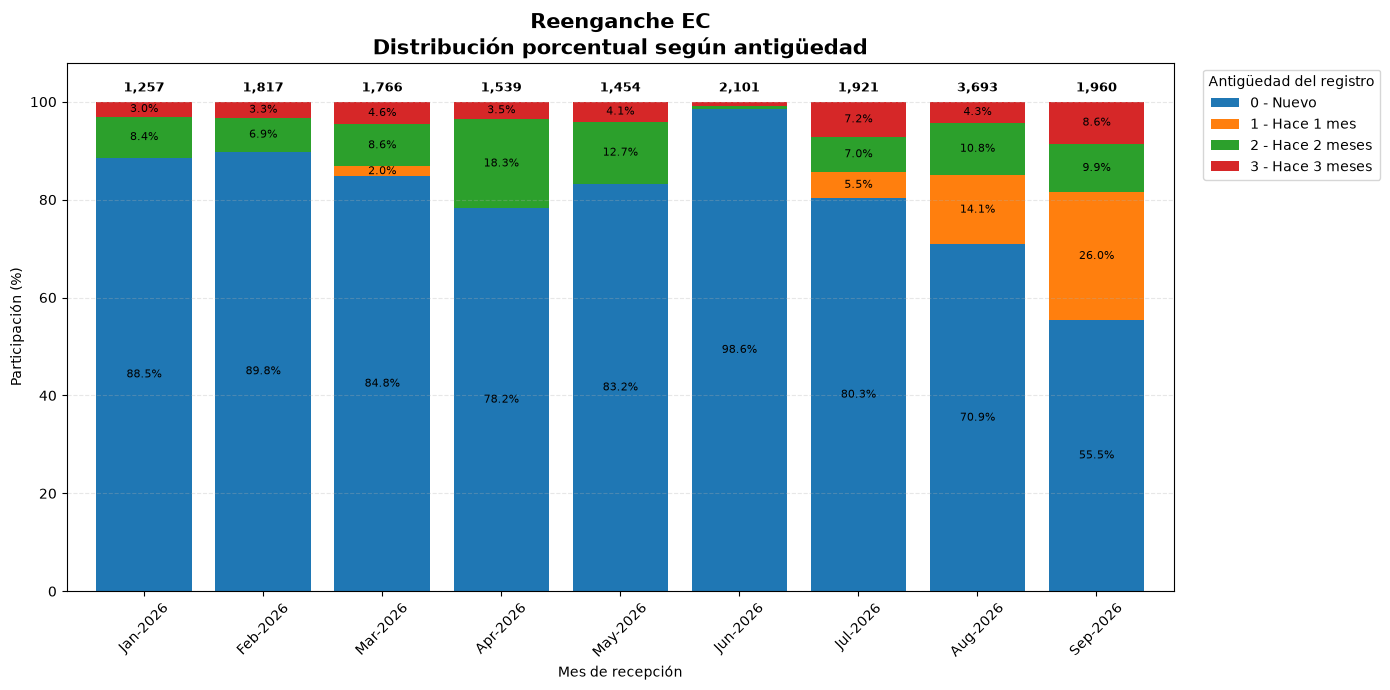

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,88.54%,0.00%,8.43%,3.02%,1257
2026-02-01,89.82%,0.00%,6.88%,3.30%,1817
2026-03-01,84.77%,2.04%,8.55%,4.64%,1766
2026-04-01,78.23%,0.00%,18.26%,3.51%,1539
2026-05-01,83.22%,0.00%,12.72%,4.06%,1454
2026-06-01,98.57%,0.00%,0.52%,0.90%,2101
2026-07-01,80.27%,5.47%,7.03%,7.24%,1921
2026-08-01,70.86%,14.13%,10.75%,4.25%,3693
2026-09-01,55.46%,26.02%,9.95%,8.57%,1960


In [22]:
tabla_ec, cantidad_ec = analizar_antiguedad(df_base_pd,"Reenganche EC")

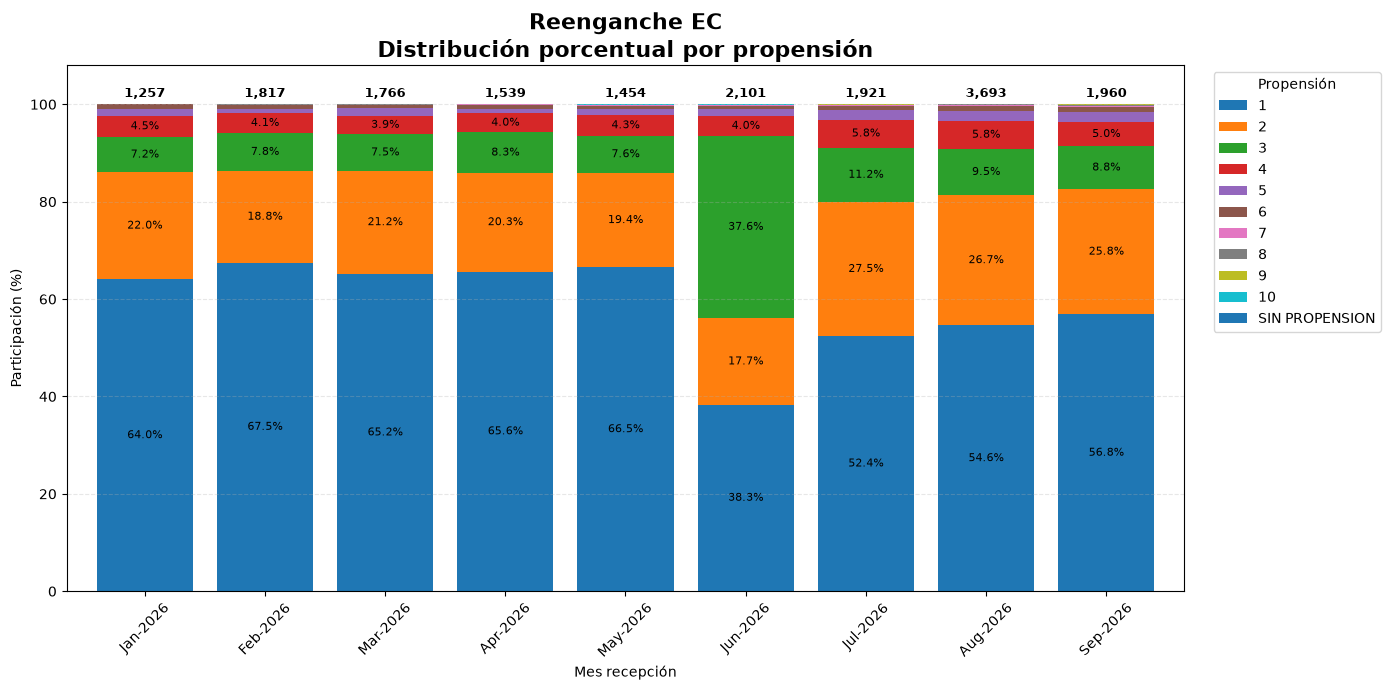

PROPENSION,1,2,3,4,5,6,7,8,9,10,SIN PROPENSION,Total Base
mes,,,,,,,,,,,,
2026-01-01,64.04%,22.04%,7.16%,4.46%,1.35%,0.95%,0.00%,0.00%,0.00%,0.00%,0.00%,1257
2026-02-01,67.47%,18.82%,7.82%,4.07%,0.94%,0.77%,0.06%,0.06%,0.00%,0.00%,0.00%,1817
2026-03-01,65.18%,21.18%,7.47%,3.85%,1.47%,0.68%,0.11%,0.06%,0.00%,0.00%,0.00%,1766
2026-04-01,65.63%,20.27%,8.32%,3.96%,0.91%,0.84%,0.06%,0.00%,0.00%,0.00%,0.00%,1539
2026-05-01,66.51%,19.39%,7.63%,4.26%,1.31%,0.55%,0.14%,0.14%,0.00%,0.07%,0.00%,1454
2026-06-01,38.32%,17.71%,37.55%,3.95%,1.52%,0.67%,0.10%,0.10%,0.05%,0.05%,0.00%,2101
2026-07-01,52.42%,27.49%,11.19%,5.78%,1.93%,0.78%,0.26%,0.10%,0.05%,0.00%,0.00%,1921
2026-08-01,54.62%,26.70%,9.53%,5.77%,1.95%,1.03%,0.22%,0.16%,0.03%,0.00%,0.00%,3693
2026-09-01,56.84%,25.77%,8.78%,5.00%,2.14%,0.97%,0.15%,0.26%,0.10%,0.00%,0.00%,1960


In [23]:
tabla_ec = analizar_propension(df_filtrado,"Reenganche EC")

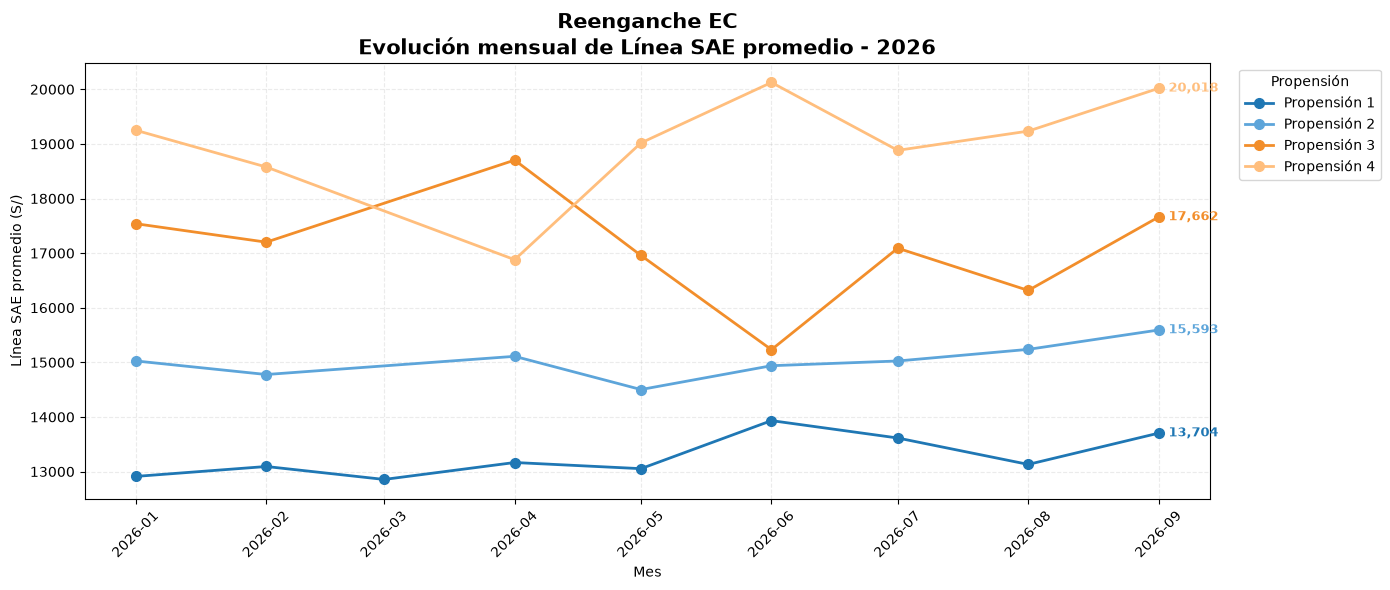

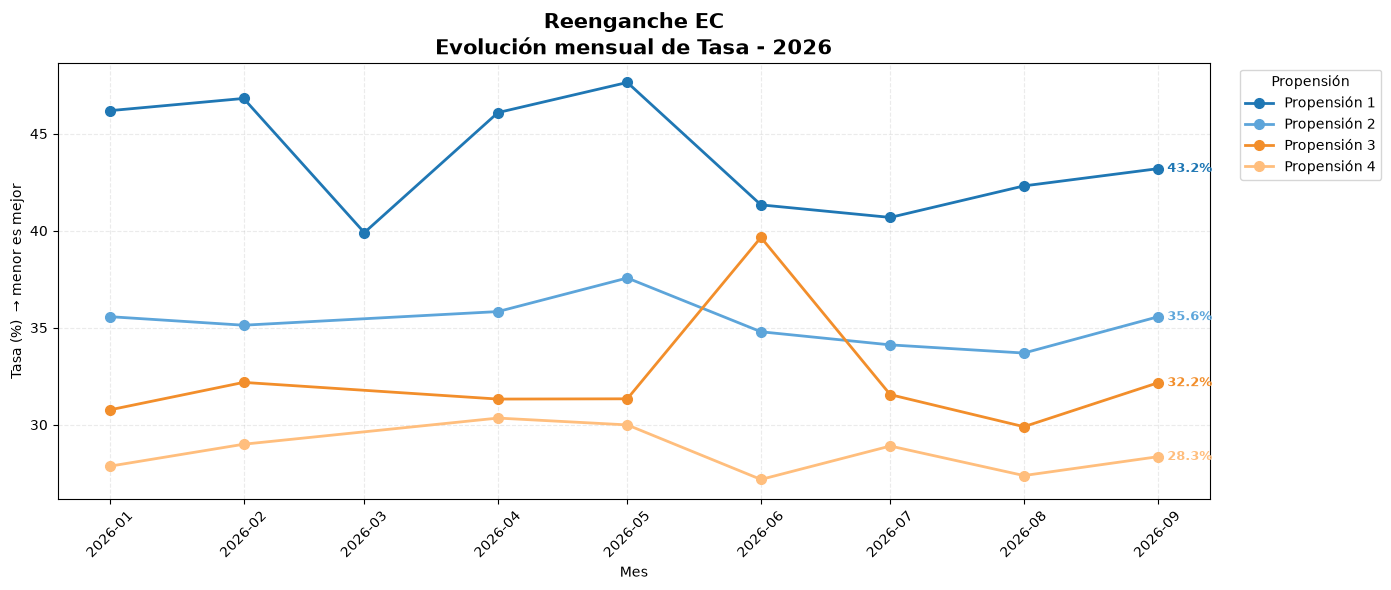

,mes,PROPENSION,LINEA_SAE_PROMEDIO,TASA,REGISTROS
0,2026-01-01,1,12911.30,46.19,805
4,2026-02-01,1,13092.90,46.82,1226
8,2026-03-01,1,12855.87,39.90,1151
12,2026-04-01,1,13165.94,46.09,1010
16,2026-05-01,1,13053.36,47.64,967
20,2026-06-01,1,13932.92,41.33,805
24,2026-07-01,1,13614.70,40.68,1007
28,2026-08-01,1,13131.04,42.31,2017
32,2026-09-01,1,13704.31,43.19,1114
1,2026-01-01,2,15025.63,35.57,277


In [24]:
tabla_reenganche = analizar_evolucion_propension(df_filtrado,"Reenganche EC")

In [40]:
query = f"""
select distinct Nombre_Campana 
From SAMANTHA.dbo.tmp_llamadas_mes
where fecha_llamada>='2026-03-01'
and (
Nombre_Campana like '%sae%'
or Nombre_Campana like '%sar%'
or Nombre_Campana like '%cd%'
)
"""
df_llamadas_diners_tc=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
print([row['Nombre_Campana' ] for row in df_llamadas_diners_tc.select('Nombre_Campana').distinct().collect()])


['2026-07 SAE', '2026-06 CD', '2026-05 CD', '2026-07 SAR', '2026-05 SAR', '2026-03 SAE', '2026-04 CD', '2026-06 DINERS CD', '2026-05 SAE', '2026-04 SAR', '2026-05 DINERS CD', '2026-06 SAE', '2026-08 CD', '2026-04 SAE', '2026-09 SAE', '2026-08 SAR', '2026-03 SAR', '2026-06 SAR', '2026-08 SAE', '2026-04 DINERS CD', '2026-09 SAR']


In [ ]:
odin.dbo.temp_cenco_llamadas

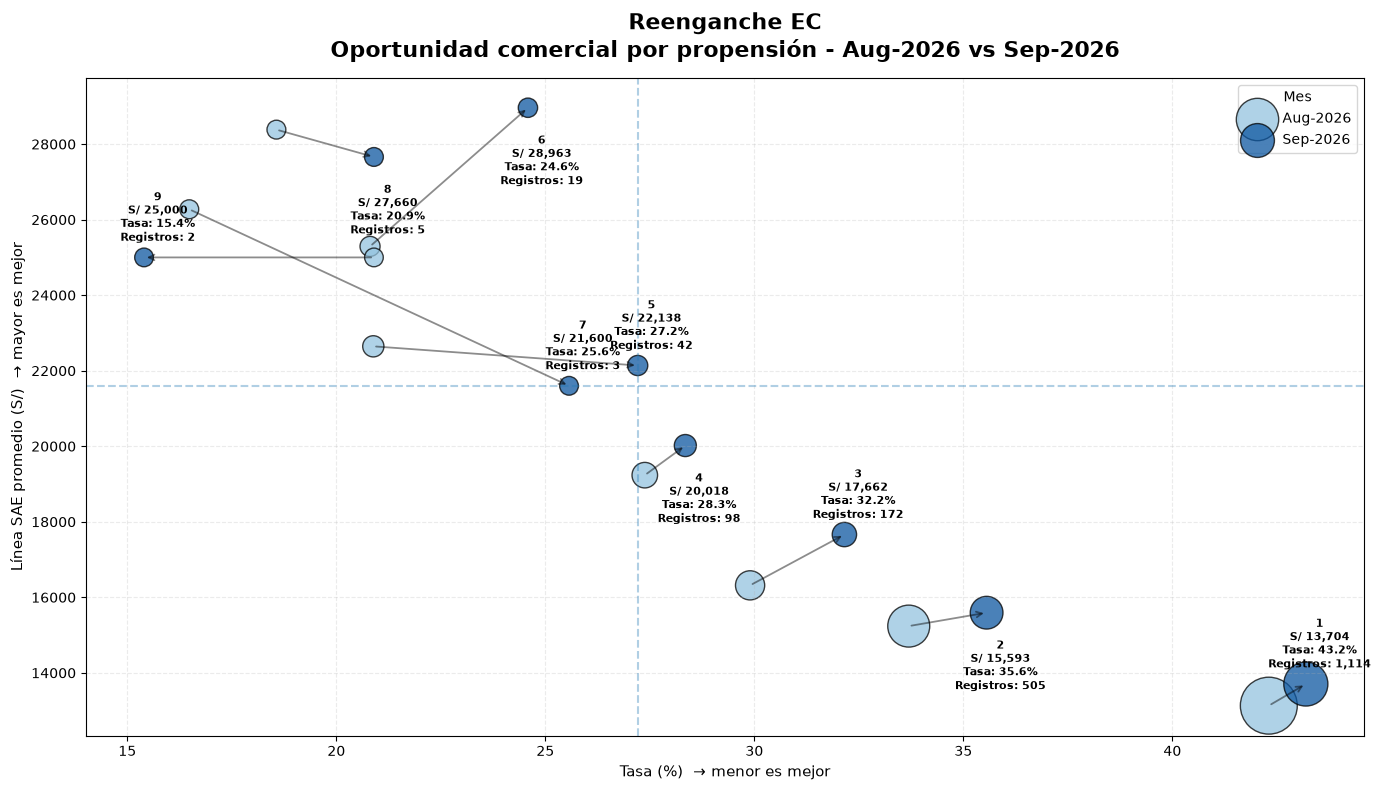

,mes,PROPENSION,LINEA_SAE_PROMEDIO,TASA,REGISTROS
0,2026-08-01,1,13131.04,42.31,2017
9,2026-09-01,1,13704.31,43.19,1114
1,2026-08-01,2,15237.63,33.69,986
10,2026-09-01,2,15592.67,35.56,505
2,2026-08-01,3,16316.76,29.90,352
11,2026-09-01,3,17662.21,32.15,172
3,2026-08-01,4,19234.27,27.38,213
12,2026-09-01,4,20018.37,28.35,98
4,2026-08-01,5,22645.83,20.88,72
13,2026-09-01,5,22138.10,27.21,42


In [25]:
tabla_ec = analizar_oportunidad_2_meses(
    df_filtrado,
    "Reenganche EC",
    meses=("2026-08", "2026-09")
)

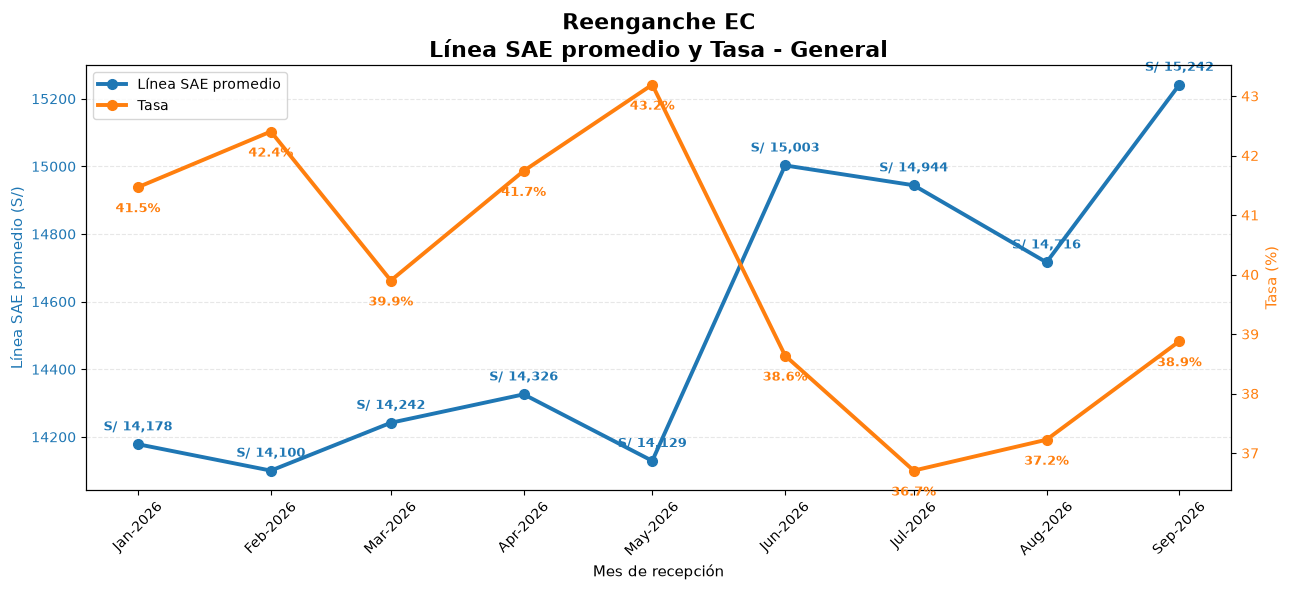

,mes,linea_sae_promedio,tasa,linea_sae_count,tea_count
0,2026-01-01,14178.28,41.47,1257,1257
1,2026-02-01,14100.28,42.40,1817,1817
2,2026-03-01,14241.79,39.90,1766,1
3,2026-04-01,14325.86,41.74,1539,1539
4,2026-05-01,14129.09,43.19,1454,1454
5,2026-06-01,15002.86,38.64,2101,2101
6,2026-07-01,14944.14,36.71,1921,1921
7,2026-08-01,14716.25,37.22,3693,3693
8,2026-09-01,15241.73,38.88,1960,1960


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================

producto_seleccionado = "Reenganche EC"

# producto_seleccionado = "EC Cliente"


# ============================================================
# 2. FILTRAR PRODUCTO
# ============================================================

df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()


# ============================================================
# 3. ASEGURAR TIPOS
# ============================================================

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

columnas_numericas = [
    "tea_sum",
    "tea_count",
    "linea_sae_sum",
    "linea_sae_count"
]

for columna in columnas_numericas:

    df_grafico[columna] = pd.to_numeric(
        df_grafico[columna],
        errors="coerce"
    ).fillna(0)


# Eliminar registros sin mes
df_grafico = df_grafico[
    df_grafico["mes"].notna()
].copy()


# ============================================================
# 4. RESUMEN GENERAL POR MES
# ============================================================

df_mensual = (
    df_grafico
    .groupby(
        "mes",
        as_index=False
    )
    .agg(

        tea_sum=(
            "tea_sum",
            "sum"
        ),

        tea_count=(
            "tea_count",
            "sum"
        ),

        linea_sae_sum=(
            "linea_sae_sum",
            "sum"
        ),

        linea_sae_count=(
            "linea_sae_count",
            "sum"
        )
    )
    .sort_values("mes")
)


# ============================================================
# 5. CALCULAR LÍNEA SAE PROMEDIO
# ============================================================

df_mensual["linea_sae_promedio"] = (
    df_mensual["linea_sae_sum"]
    /
    df_mensual["linea_sae_count"]
)


# ============================================================
# 6. CALCULAR TASA
# ============================================================

df_mensual["tasa"] = (
    df_mensual["tea_sum"]
    /
    df_mensual["tea_count"]
) * 100


# Evitar infinitos si algún count fuera 0
df_mensual["linea_sae_promedio"] = (
    df_mensual["linea_sae_promedio"]
    .replace([float("inf"), float("-inf")], pd.NA)
)

df_mensual["tasa"] = (
    df_mensual["tasa"]
    .replace([float("inf"), float("-inf")], pd.NA)
)


# ============================================================
# 7. GRÁFICO GENERAL
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(13, 6)
)


# ============================================================
# LÍNEA SAE - AZUL
# ============================================================

linea1, = ax1.plot(

    df_mensual["mes"],

    df_mensual["linea_sae_promedio"],

    marker="o",

    linewidth=2.8,

    markersize=7,

    color="#1f77b4",

    label="Línea SAE promedio"
)


# ============================================================
# ETIQUETAS LÍNEA SAE
# ============================================================

for mes, valor in zip(

    df_mensual["mes"],

    df_mensual["linea_sae_promedio"]
):

    if pd.notna(valor):

        ax1.annotate(

            f"S/ {valor:,.0f}",

            xy=(
                mes,
                valor
            ),

            xytext=(
                0,
                10
            ),

            textcoords="offset points",

            ha="center",

            fontsize=9,

            fontweight="bold",

            color="#1f77b4"
        )


# ============================================================
# EJE IZQUIERDO
# ============================================================

ax1.set_ylabel(
    "Línea SAE promedio (S/)",
    color="#1f77b4",
    fontsize=11
)

ax1.tick_params(
    axis="y",
    labelcolor="#1f77b4"
)

ax1.set_xlabel(
    "Mes de recepción",
    fontsize=11
)


# ============================================================
# 8. SEGUNDO EJE - TASA
# ============================================================

ax2 = ax1.twinx()


# ============================================================
# TASA - NARANJA
# ============================================================

linea2, = ax2.plot(

    df_mensual["mes"],

    df_mensual["tasa"],

    marker="o",

    linewidth=2.8,

    markersize=7,

    color="#ff7f0e",

    label="Tasa"
)


# ============================================================
# ETIQUETAS TASA
# ============================================================

for mes, valor in zip(

    df_mensual["mes"],

    df_mensual["tasa"]
):

    if pd.notna(valor):

        ax2.annotate(

            f"{valor:.1f}%",

            xy=(
                mes,
                valor
            ),

            xytext=(
                0,
                -18
            ),

            textcoords="offset points",

            ha="center",

            fontsize=9,

            fontweight="bold",

            color="#ff7f0e"
        )


# ============================================================
# EJE DERECHO
# ============================================================

ax2.set_ylabel(
    "Tasa (%)",
    color="#ff7f0e",
    fontsize=11
)

ax2.tick_params(
    axis="y",
    labelcolor="#ff7f0e"
)


# ============================================================
# 9. EJE X
# ============================================================

ax1.set_xticks(
    df_mensual["mes"]
)

ax1.set_xticklabels(

    [
        fecha.strftime("%b-%Y")
        for fecha in df_mensual["mes"]
    ],

    rotation=45
)


# ============================================================
# 10. TÍTULO
# ============================================================

ax1.set_title(

    f"{producto_seleccionado}\n"
    "Línea SAE promedio y Tasa - General",

    fontsize=16,

    fontweight="bold"
)


# ============================================================
# 11. GRID
# ============================================================

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


# ============================================================
# 12. LEYENDA
# ============================================================

lineas = [
    linea1,
    linea2
]

ax1.legend(

    lineas,

    [
        linea.get_label()
        for linea in lineas
    ],

    loc="upper left"
)


plt.tight_layout()

plt.show()


# ============================================================
# 13. TABLA UTILIZADA
# ============================================================

display(

    df_mensual[
        [
            "mes",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count",
            "tea_count"
        ]
    ].round(2)

)

In [36]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # ============================================================
# # PRODUCTO
# # ============================================================
# producto_seleccionado = "Reenganche EC"

# # Orden de propensiones
# orden_propension = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]

# # ============================================================
# # 1. FILTRAR PRODUCTO
# # ============================================================
# df_plot = df_filtrado[
#     df_filtrado["producto"] == producto_seleccionado
# ].copy()

# df_plot["mes"] = pd.to_datetime(
#     df_plot["mes"],
#     errors="coerce"
# )

# df_plot["PROPENSION"] = (
#     df_plot["PROPENSION"]
#     .astype(str)
#     .str.strip()
# )

# # Quedarnos solo con propensiones válidas
# df_plot = df_plot[
#     df_plot["PROPENSION"].isin(orden_propension)
# ].copy()

# # ============================================================
# # 2. AGRUPAR POR MES Y PROPENSION
# # ============================================================
# df_mensual_propension = (
#     df_plot
#     .groupby(
#         ["mes", "PROPENSION"],
#         as_index=False
#     )
#     .agg(
#         tea_sum=("tea_sum", "sum"),
#         tea_count=("tea_count", "sum"),
#         linea_sae_sum=("linea_sae_sum", "sum"),
#         linea_sae_count=("linea_sae_count", "sum")
#     )
# )

# # ============================================================
# # 3. CALCULAR INDICADORES
# # ============================================================
# df_mensual_propension["linea_sae_promedio"] = (
#     df_mensual_propension["linea_sae_sum"]
#     / df_mensual_propension["linea_sae_count"]
# )

# df_mensual_propension["tasa"] = (
#     df_mensual_propension["tea_sum"]
#     / df_mensual_propension["tea_count"]
# ) * 100

# # ============================================================
# # 4. GRAFICO POR PROPENSION
# # ============================================================
# for propension in orden_propension:

#     df_prop = (
#         df_mensual_propension[
#             df_mensual_propension["PROPENSION"] == propension
#         ]
#         .sort_values("mes")
#         .copy()
#     )

#     if df_prop.empty:
#         continue

#     fig, ax1 = plt.subplots(figsize=(13, 6))

#     # ========================================================
#     # LINEA SAE - AZUL
#     # ========================================================
#     linea1, = ax1.plot(
#         df_prop["mes"],
#         df_prop["linea_sae_promedio"],
#         marker="o",
#         linewidth=2.8,
#         markersize=7,
#         color="#1f77b4",
#         label="Línea SAE promedio"
#     )

#     for mes, valor in zip(
#         df_prop["mes"],
#         df_prop["linea_sae_promedio"]
#     ):
#         ax1.annotate(
#             f"S/ {valor:,.0f}",
#             xy=(mes, valor),
#             xytext=(0, 10),
#             textcoords="offset points",
#             ha="center",
#             fontsize=9,
#             fontweight="bold",
#             color="#1f77b4"
#         )

#     ax1.set_ylabel(
#         "Línea SAE promedio (S/)",
#         color="#1f77b4"
#     )

#     ax1.tick_params(
#         axis="y",
#         labelcolor="#1f77b4"
#     )

#     ax1.set_xlabel("Mes de recepción")

#     # ========================================================
#     # TASA - NARANJA
#     # ========================================================
#     ax2 = ax1.twinx()

#     linea2, = ax2.plot(
#         df_prop["mes"],
#         df_prop["tasa"],
#         marker="o",
#         linewidth=2.8,
#         markersize=7,
#         color="#ff7f0e",
#         label="Tasa"
#     )

#     for mes, valor in zip(
#         df_prop["mes"],
#         df_prop["tasa"]
#     ):
#         ax2.annotate(
#             f"{valor:.1f}%",
#             xy=(mes, valor),
#             xytext=(0, -18),
#             textcoords="offset points",
#             ha="center",
#             fontsize=9,
#             fontweight="bold",
#             color="#ff7f0e"
#         )

#     ax2.set_ylabel(
#         "Tasa (%)",
#         color="#ff7f0e"
#     )

#     ax2.tick_params(
#         axis="y",
#         labelcolor="#ff7f0e"
#     )

#     # ========================================================
#     # EJE X
#     # ========================================================
#     ax1.set_xticks(df_prop["mes"])

#     ax1.set_xticklabels(
#         [
#             fecha.strftime("%b-%Y")
#             for fecha in df_prop["mes"]
#         ],
#         rotation=45
#     )

#     # ========================================================
#     # TITULO
#     # ========================================================
#     ax1.set_title(
#         f"{producto_seleccionado} - Propensión {propension}\n"
#         "Línea SAE promedio y Tasa",
#         fontsize=16,
#         fontweight="bold"
#     )

#     ax1.grid(
#         axis="y",
#         linestyle="--",
#         alpha=0.3
#     )

#     # ========================================================
#     # LEYENDA
#     # ========================================================
#     lineas = [linea1, linea2]

#     ax1.legend(
#         lineas,
#         [l.get_label() for l in lineas],
#         loc="upper left"
#     )

#     plt.tight_layout()
#     plt.show()

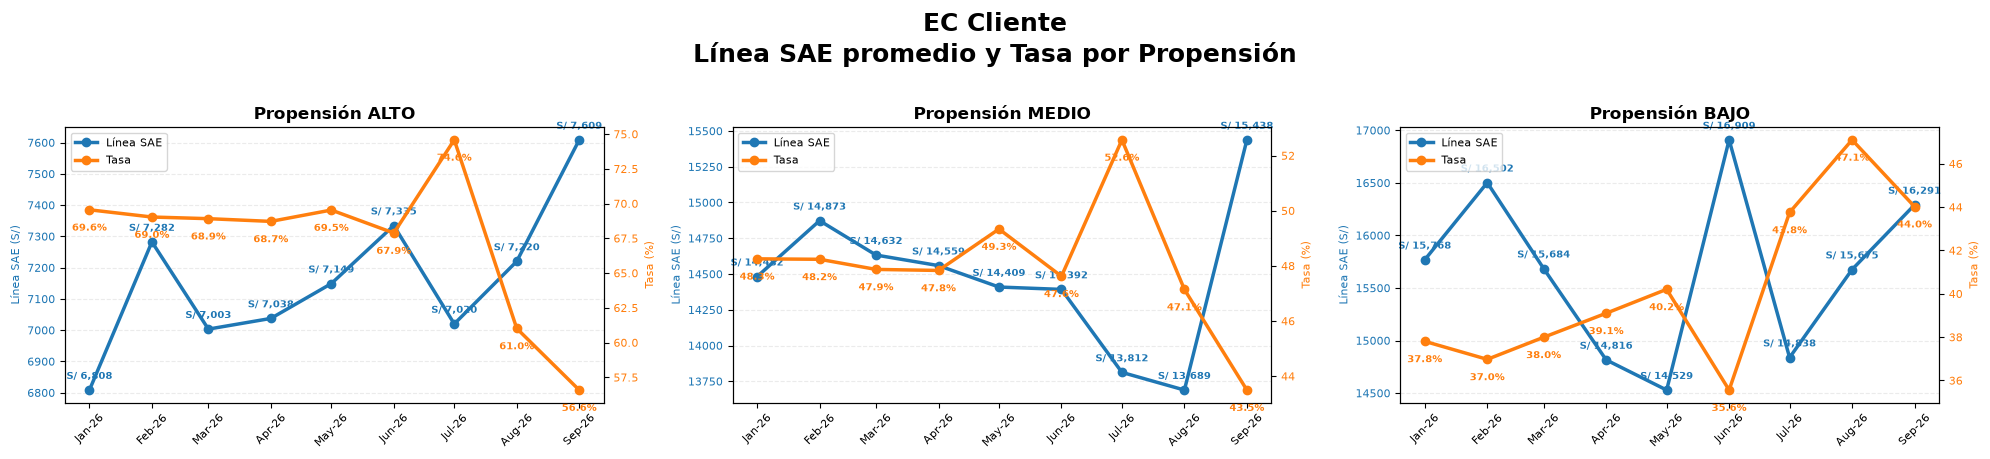

,mes,PROPENSION,linea_sae_promedio,tasa,linea_sae_count,tea_count
0,2026-01-01,ALTO,6808.43,69.55,5958,5958
3,2026-02-01,ALTO,7282.27,69.03,5555,5555
6,2026-03-01,ALTO,7003.37,68.91,5170,5170
9,2026-04-01,ALTO,7037.52,68.72,6069,6069
12,2026-05-01,ALTO,7148.87,69.53,4459,4459
15,2026-06-01,ALTO,7334.61,67.88,6030,6030
18,2026-07-01,ALTO,7019.99,74.58,6159,6159
21,2026-08-01,ALTO,7220.05,61.01,7047,7047
24,2026-09-01,ALTO,7608.65,56.58,3248,3248
2,2026-01-01,MEDIO,14481.63,48.25,14597,14597


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# 1. CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================

# producto_seleccionado = "Reenganche EC"

producto_seleccionado = "EC Cliente"


# ============================================================
# 2. ORDEN DE PROPENSIÓN SEGÚN PRODUCTO
# ============================================================

orden_por_producto = {

    "Reenganche EC": [
        "1",
        "2",
        "3",
        "4",
        "5",
        "6",
        "7",
        "8",
        "9",
        "10",
        "SIN PROPENSION"
    ],

    "EC Cliente": [
        "ALTO",
        "MEDIO",
        "BAJO",
    ]
}


# Obtener orden correspondiente al producto
orden_propension = orden_por_producto[producto_seleccionado]


# ============================================================
# 3. FILTRAR PRODUCTO
# ============================================================

df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()


# ============================================================
# 4. ASEGURAR TIPOS
# ============================================================

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)


# Columnas numéricas
columnas_numericas = [
    "tea_sum",
    "tea_count",
    "linea_sae_sum",
    "linea_sae_count"
]

for col in columnas_numericas:

    df_grafico[col] = pd.to_numeric(
        df_grafico[col],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 5. FILTRAR SOLO PROPENSIONES DEL PRODUCTO
# ============================================================

df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()


# ============================================================
# 6. RESUMEN POR MES Y PROPENSIÓN
# ============================================================

df_mensual_propension = (
    df_grafico
    .groupby(
        [
            "mes",
            "PROPENSION"
        ],
        as_index=False
    )
    .agg(

        tea_sum=(
            "tea_sum",
            "sum"
        ),

        tea_count=(
            "tea_count",
            "sum"
        ),

        linea_sae_sum=(
            "linea_sae_sum",
            "sum"
        ),

        linea_sae_count=(
            "linea_sae_count",
            "sum"
        )
    )
)


# ============================================================
# 7. CALCULAR LÍNEA SAE PROMEDIO
# ============================================================

df_mensual_propension["linea_sae_promedio"] = (
    df_mensual_propension["linea_sae_sum"]
    /
    df_mensual_propension["linea_sae_count"]
)


# ============================================================
# 8. CALCULAR TASA
# ============================================================

df_mensual_propension["tasa"] = (
    df_mensual_propension["tea_sum"]
    /
    df_mensual_propension["tea_count"]
) * 100


# ============================================================
# 9. ORDENAR PROPENSIONES
# ============================================================

df_mensual_propension["PROPENSION"] = pd.Categorical(
    df_mensual_propension["PROPENSION"],
    categories=orden_propension,
    ordered=True
)

df_mensual_propension = (
    df_mensual_propension
    .sort_values(
        [
            "PROPENSION",
            "mes"
        ]
    )
)


# ============================================================
# 10. DEFINIR TAMAÑO AUTOMÁTICO DE LA MATRIZ
# ============================================================

numero_propensiones = len(orden_propension)

# 3 columnas
ncols = 3

# Filas necesarias
nrows = math.ceil(
    numero_propensiones / ncols
)


# ============================================================
# 11. CREAR MATRIZ DE GRÁFICOS
# ============================================================

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        20,
        nrows * 4.5
    )
)

# Convertir siempre en vector
axes = (
    axes.flatten()
    if hasattr(axes, "flatten")
    else [axes]
)


# ============================================================
# 12. GRAFICAR CADA PROPENSIÓN
# ============================================================

for i, propension in enumerate(orden_propension):

    ax1 = axes[i]

    df_prop = (
        df_mensual_propension[
            df_mensual_propension["PROPENSION"] == propension
        ]
        .sort_values("mes")
        .copy()
    )


    # --------------------------------------------------------
    # SI NO EXISTEN DATOS
    # --------------------------------------------------------

    if df_prop.empty:

        ax1.set_title(
            f"Propensión {propension}\nSin información",
            fontsize=11,
            fontweight="bold"
        )

        ax1.axis("off")

        continue


    # ========================================================
    # LÍNEA SAE - AZUL
    # ========================================================

    linea1, = ax1.plot(

        df_prop["mes"],

        df_prop["linea_sae_promedio"],

        marker="o",

        linewidth=2.5,

        markersize=6,

        color="#1f77b4",

        label="Línea SAE"
    )


    # ========================================================
    # ETIQUETAS LÍNEA SAE
    # ========================================================

    for mes, valor in zip(

        df_prop["mes"],

        df_prop["linea_sae_promedio"]
    ):

        if pd.notna(valor):

            ax1.annotate(

                f"S/ {valor:,.0f}",

                xy=(
                    mes,
                    valor
                ),

                xytext=(
                    0,
                    8
                ),

                textcoords="offset points",

                ha="center",

                fontsize=7,

                fontweight="bold",

                color="#1f77b4"
            )


    # ========================================================
    # FORMATO EJE IZQUIERDO
    # ========================================================

    ax1.set_ylabel(
        "Línea SAE (S/)",
        color="#1f77b4",
        fontsize=8
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#1f77b4",
        labelsize=8
    )


    # ========================================================
    # SEGUNDO EJE
    # ========================================================

    ax2 = ax1.twinx()


    # ========================================================
    # TASA - NARANJA
    # ========================================================

    linea2, = ax2.plot(

        df_prop["mes"],

        df_prop["tasa"],

        marker="o",

        linewidth=2.5,

        markersize=6,

        color="#ff7f0e",

        label="Tasa"
    )


    # ========================================================
    # ETIQUETAS TASA
    # ========================================================

    for mes, valor in zip(

        df_prop["mes"],

        df_prop["tasa"]
    ):

        if pd.notna(valor):

            ax2.annotate(

                f"{valor:.1f}%",

                xy=(
                    mes,
                    valor
                ),

                xytext=(
                    0,
                    -15
                ),

                textcoords="offset points",

                ha="center",

                fontsize=7,

                fontweight="bold",

                color="#ff7f0e"
            )


    # ========================================================
    # FORMATO EJE DERECHO
    # ========================================================

    ax2.set_ylabel(
        "Tasa (%)",
        color="#ff7f0e",
        fontsize=8
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#ff7f0e",
        labelsize=8
    )


    # ========================================================
    # TÍTULO DE CADA GRÁFICO
    # ========================================================

    ax1.set_title(

        f"Propensión {propension}",

        fontsize=12,

        fontweight="bold"
    )


    # ========================================================
    # EJE X
    # ========================================================

    ax1.set_xticks(
        df_prop["mes"]
    )

    ax1.set_xticklabels(

        [
            fecha.strftime("%b-%y")
            for fecha in df_prop["mes"]
        ],

        rotation=45,

        fontsize=8
    )


    # ========================================================
    # GRID
    # ========================================================

    ax1.grid(

        axis="y",

        linestyle="--",

        alpha=0.25
    )


    # ========================================================
    # LEYENDA
    # ========================================================

    ax1.legend(

        [
            linea1,
            linea2
        ],

        [
            "Línea SAE",
            "Tasa"
        ],

        loc="upper left",

        fontsize=8
    )


# ============================================================
# 13. OCULTAR ESPACIOS VACÍOS
# ============================================================

for j in range(
    numero_propensiones,
    len(axes)
):

    axes[j].axis("off")


# ============================================================
# 14. TÍTULO GENERAL
# ============================================================

fig.suptitle(

    f"{producto_seleccionado}\n"
    "Línea SAE promedio y Tasa por Propensión",

    fontsize=18,

    fontweight="bold",

    y=1.01
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. TABLA UTILIZADA
# ============================================================

display(

    df_mensual_propension[
        [
            "mes",
            "PROPENSION",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count",
            "tea_count"
        ]
    ].round(2)

)

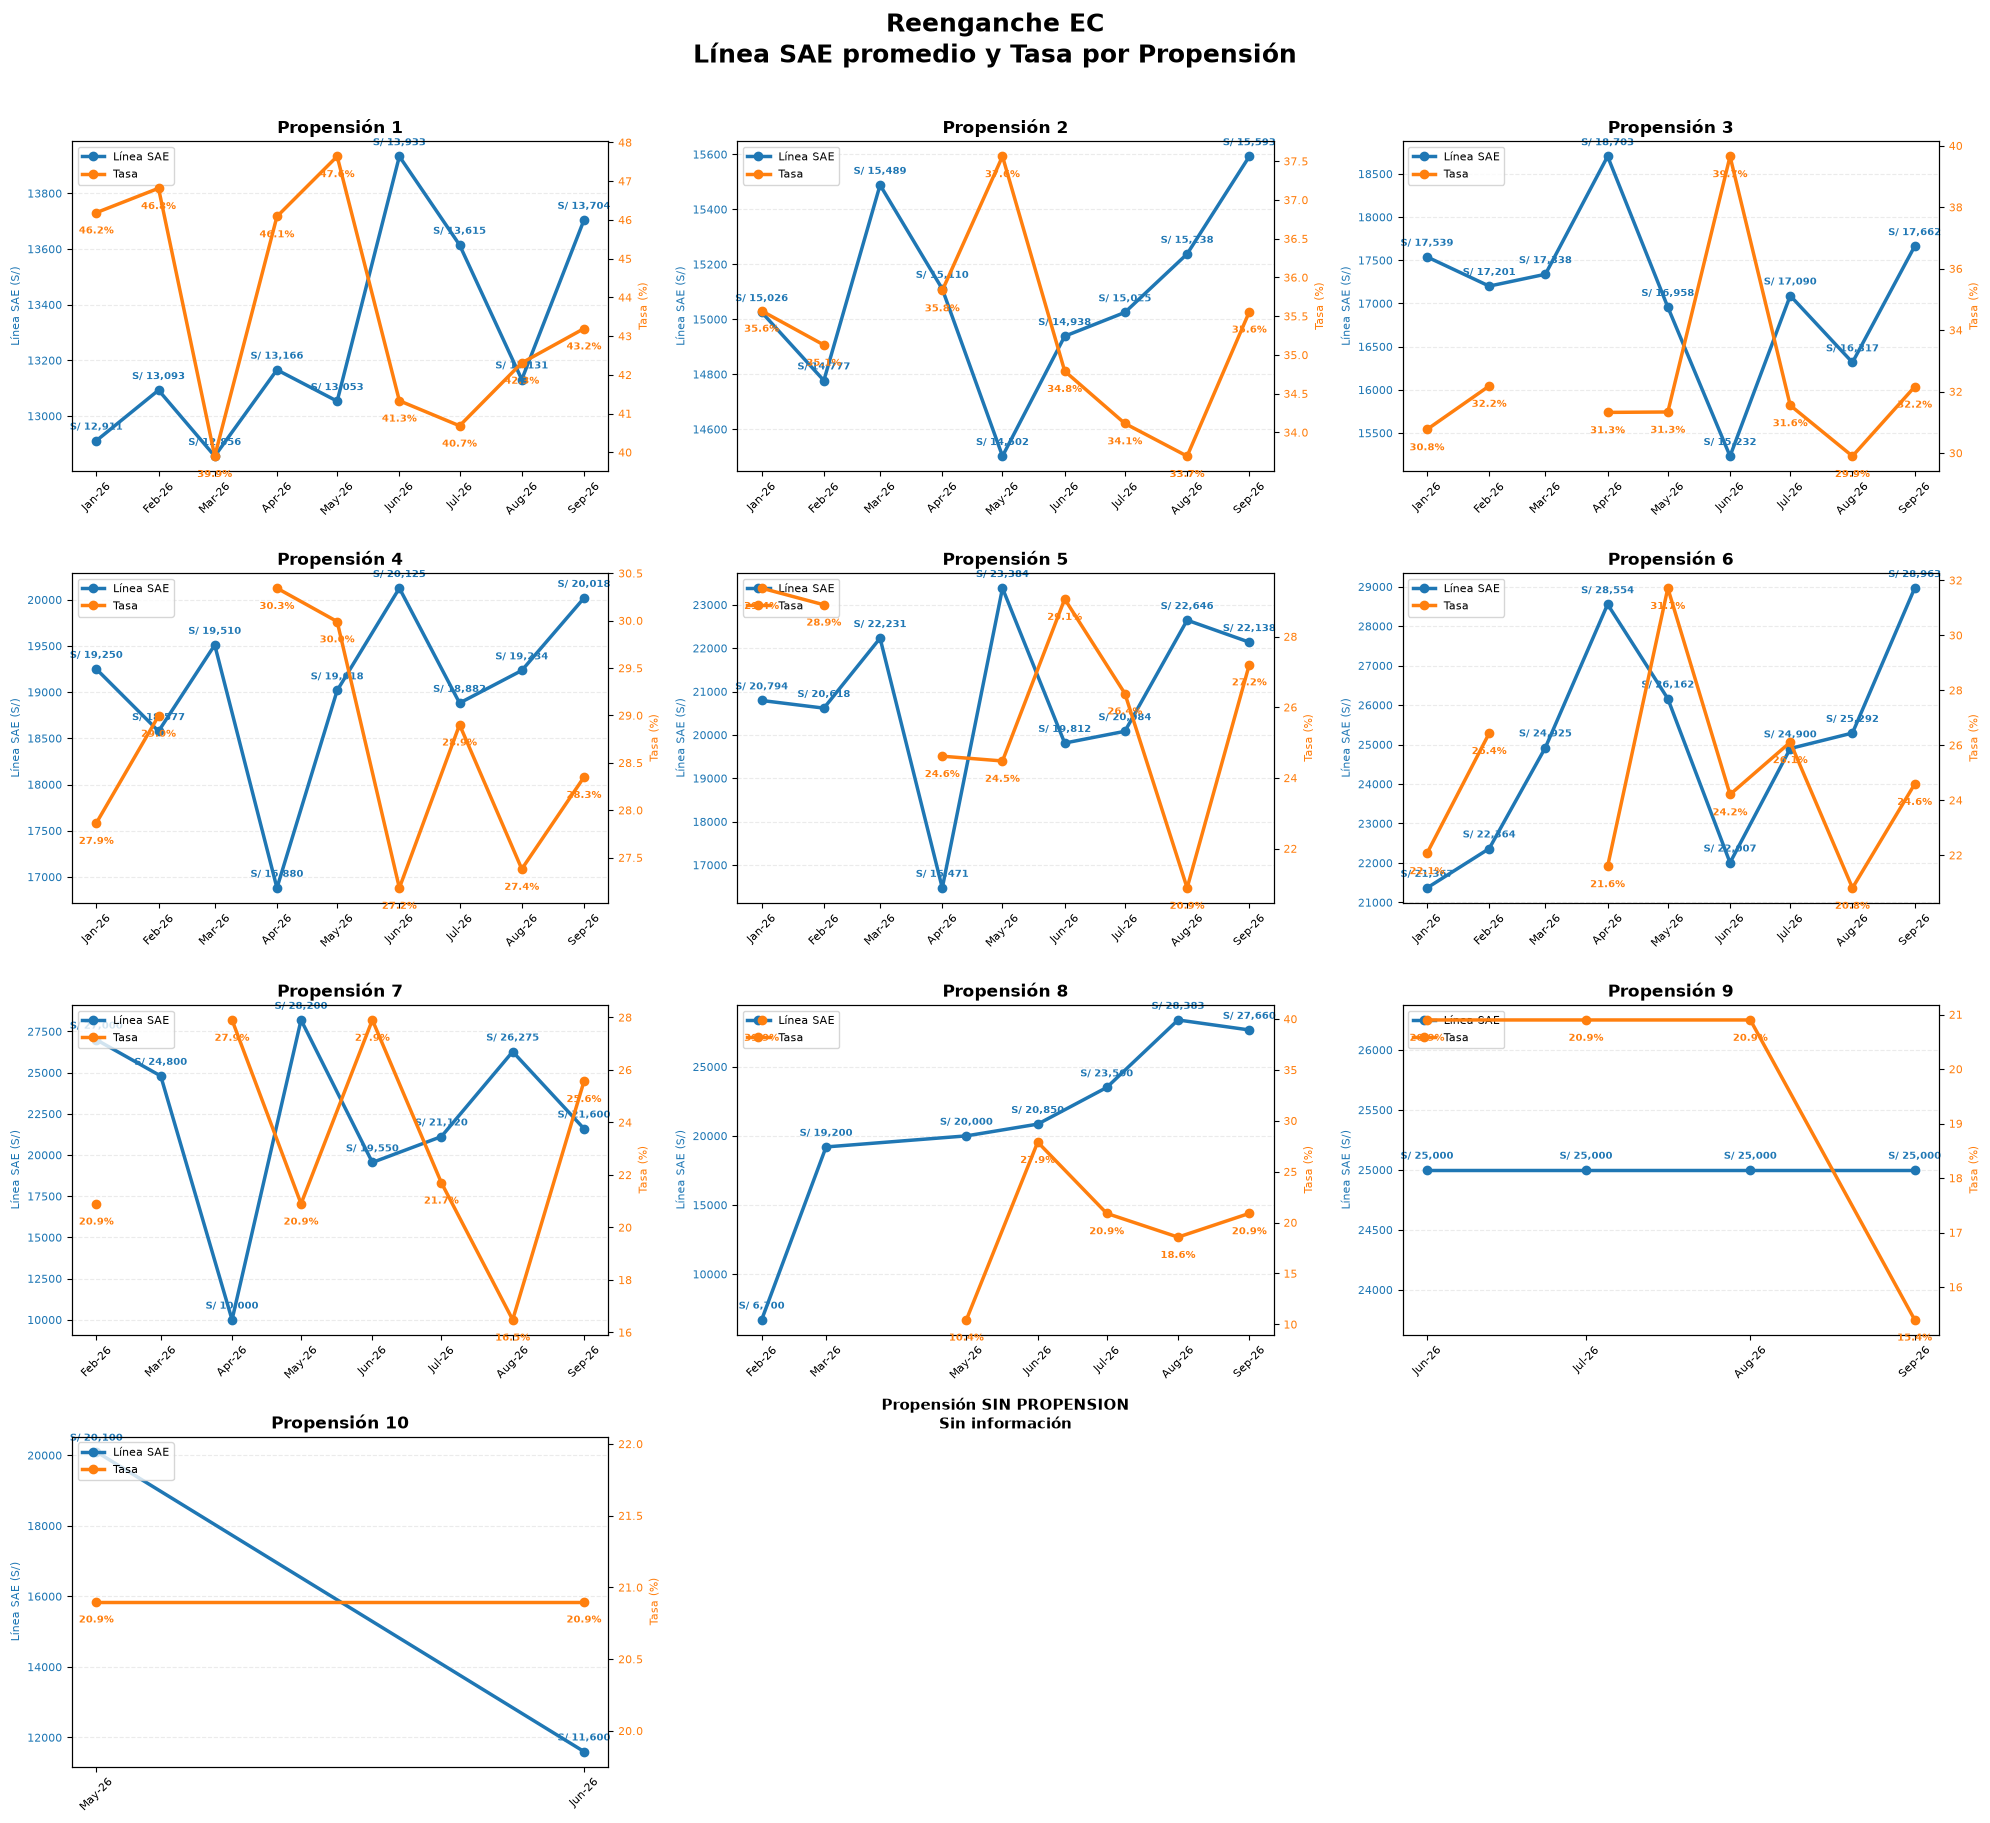

,mes,PROPENSION,linea_sae_promedio,tasa,linea_sae_count,tea_count
0,2026-01-01,1,12911.30,46.19,805,805
6,2026-02-01,1,13092.90,46.82,1226,1226
14,2026-03-01,1,12855.87,39.90,1151,1
22,2026-04-01,1,13165.94,46.09,1010,1010
29,2026-05-01,1,13053.36,47.64,967,967
...,...,...,...,...,...,...
56,2026-07-01,9,25000.00,20.90,1,1
65,2026-08-01,9,25000.00,20.90,1,1
74,2026-09-01,9,25000.00,15.40,2,2
30,2026-05-01,10,20100.00,20.90,1,1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# 1. CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================

producto_seleccionado = "Reenganche EC"

# producto_seleccionado = "EC Cliente"


# ============================================================
# 2. ORDEN DE PROPENSIÓN SEGÚN PRODUCTO
# ============================================================

orden_por_producto = {

    "Reenganche EC": [
        "1",
        "2",
        "3",
        "4",
        "5",
        "6",
        "7",
        "8",
        "9",
        "10",
        "SIN PROPENSION"
    ],

    "EC Cliente": [
        "ALTO",
        "MEDIO",
        "BAJO",
        "SIN PROPENSION"
    ]
}


# Obtener orden correspondiente al producto
orden_propension = orden_por_producto[producto_seleccionado]


# ============================================================
# 3. FILTRAR PRODUCTO
# ============================================================

df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()


# ============================================================
# 4. ASEGURAR TIPOS
# ============================================================

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)


# Columnas numéricas
columnas_numericas = [
    "tea_sum",
    "tea_count",
    "linea_sae_sum",
    "linea_sae_count"
]

for col in columnas_numericas:

    df_grafico[col] = pd.to_numeric(
        df_grafico[col],
        errors="coerce"
    ).fillna(0)


# ============================================================
# 5. FILTRAR SOLO PROPENSIONES DEL PRODUCTO
# ============================================================

df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()


# ============================================================
# 6. RESUMEN POR MES Y PROPENSIÓN
# ============================================================

df_mensual_propension = (
    df_grafico
    .groupby(
        [
            "mes",
            "PROPENSION"
        ],
        as_index=False
    )
    .agg(

        tea_sum=(
            "tea_sum",
            "sum"
        ),

        tea_count=(
            "tea_count",
            "sum"
        ),

        linea_sae_sum=(
            "linea_sae_sum",
            "sum"
        ),

        linea_sae_count=(
            "linea_sae_count",
            "sum"
        )
    )
)


# ============================================================
# 7. CALCULAR LÍNEA SAE PROMEDIO
# ============================================================

df_mensual_propension["linea_sae_promedio"] = (
    df_mensual_propension["linea_sae_sum"]
    /
    df_mensual_propension["linea_sae_count"]
)


# ============================================================
# 8. CALCULAR TASA
# ============================================================

df_mensual_propension["tasa"] = (
    df_mensual_propension["tea_sum"]
    /
    df_mensual_propension["tea_count"]
) * 100


# ============================================================
# 9. ORDENAR PROPENSIONES
# ============================================================

df_mensual_propension["PROPENSION"] = pd.Categorical(
    df_mensual_propension["PROPENSION"],
    categories=orden_propension,
    ordered=True
)

df_mensual_propension = (
    df_mensual_propension
    .sort_values(
        [
            "PROPENSION",
            "mes"
        ]
    )
)


# ============================================================
# 10. DEFINIR TAMAÑO AUTOMÁTICO DE LA MATRIZ
# ============================================================

numero_propensiones = len(orden_propension)

# 3 columnas
ncols = 3

# Filas necesarias
nrows = math.ceil(
    numero_propensiones / ncols
)


# ============================================================
# 11. CREAR MATRIZ DE GRÁFICOS
# ============================================================

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        20,
        nrows * 4.5
    )
)

# Convertir siempre en vector
axes = (
    axes.flatten()
    if hasattr(axes, "flatten")
    else [axes]
)


# ============================================================
# 12. GRAFICAR CADA PROPENSIÓN
# ============================================================

for i, propension in enumerate(orden_propension):

    ax1 = axes[i]

    df_prop = (
        df_mensual_propension[
            df_mensual_propension["PROPENSION"] == propension
        ]
        .sort_values("mes")
        .copy()
    )


    # --------------------------------------------------------
    # SI NO EXISTEN DATOS
    # --------------------------------------------------------

    if df_prop.empty:

        ax1.set_title(
            f"Propensión {propension}\nSin información",
            fontsize=11,
            fontweight="bold"
        )

        ax1.axis("off")

        continue


    # ========================================================
    # LÍNEA SAE - AZUL
    # ========================================================

    linea1, = ax1.plot(

        df_prop["mes"],

        df_prop["linea_sae_promedio"],

        marker="o",

        linewidth=2.5,

        markersize=6,

        color="#1f77b4",

        label="Línea SAE"
    )


    # ========================================================
    # ETIQUETAS LÍNEA SAE
    # ========================================================

    for mes, valor in zip(

        df_prop["mes"],

        df_prop["linea_sae_promedio"]
    ):

        if pd.notna(valor):

            ax1.annotate(

                f"S/ {valor:,.0f}",

                xy=(
                    mes,
                    valor
                ),

                xytext=(
                    0,
                    8
                ),

                textcoords="offset points",

                ha="center",

                fontsize=7,

                fontweight="bold",

                color="#1f77b4"
            )


    # ========================================================
    # FORMATO EJE IZQUIERDO
    # ========================================================

    ax1.set_ylabel(
        "Línea SAE (S/)",
        color="#1f77b4",
        fontsize=8
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#1f77b4",
        labelsize=8
    )


    # ========================================================
    # SEGUNDO EJE
    # ========================================================

    ax2 = ax1.twinx()


    # ========================================================
    # TASA - NARANJA
    # ========================================================

    linea2, = ax2.plot(

        df_prop["mes"],

        df_prop["tasa"],

        marker="o",

        linewidth=2.5,

        markersize=6,

        color="#ff7f0e",

        label="Tasa"
    )


    # ========================================================
    # ETIQUETAS TASA
    # ========================================================

    for mes, valor in zip(

        df_prop["mes"],

        df_prop["tasa"]
    ):

        if pd.notna(valor):

            ax2.annotate(

                f"{valor:.1f}%",

                xy=(
                    mes,
                    valor
                ),

                xytext=(
                    0,
                    -15
                ),

                textcoords="offset points",

                ha="center",

                fontsize=7,

                fontweight="bold",

                color="#ff7f0e"
            )


    # ========================================================
    # FORMATO EJE DERECHO
    # ========================================================

    ax2.set_ylabel(
        "Tasa (%)",
        color="#ff7f0e",
        fontsize=8
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#ff7f0e",
        labelsize=8
    )


    # ========================================================
    # TÍTULO DE CADA GRÁFICO
    # ========================================================

    ax1.set_title(

        f"Propensión {propension}",

        fontsize=12,

        fontweight="bold"
    )


    # ========================================================
    # EJE X
    # ========================================================

    ax1.set_xticks(
        df_prop["mes"]
    )

    ax1.set_xticklabels(

        [
            fecha.strftime("%b-%y")
            for fecha in df_prop["mes"]
        ],

        rotation=45,

        fontsize=8
    )


    # ========================================================
    # GRID
    # ========================================================

    ax1.grid(

        axis="y",

        linestyle="--",

        alpha=0.25
    )


    # ========================================================
    # LEYENDA
    # ========================================================

    ax1.legend(

        [
            linea1,
            linea2
        ],

        [
            "Línea SAE",
            "Tasa"
        ],

        loc="upper left",

        fontsize=8
    )


# ============================================================
# 13. OCULTAR ESPACIOS VACÍOS
# ============================================================

for j in range(
    numero_propensiones,
    len(axes)
):

    axes[j].axis("off")


# ============================================================
# 14. TÍTULO GENERAL
# ============================================================

fig.suptitle(

    f"{producto_seleccionado}\n"
    "Línea SAE promedio y Tasa por Propensión",

    fontsize=18,

    fontweight="bold",

    y=1.01
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. TABLA UTILIZADA
# ============================================================

display(

    df_mensual_propension[
        [
            "mes",
            "PROPENSION",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count",
            "tea_count"
        ]
    ].round(2)

)

In [47]:
import numpy as np

# Convertimos temporalmente PROPENSION a número
prop_num = pd.to_numeric(
    df_mensual_propension["PROPENSION"],
    errors="coerce"
)

df_mensual_propension["SEGMENTO_PROPENSION"] = np.select(
    [
        prop_num.between(1, 2),
        prop_num.between(3, 4),
        prop_num.between(5, 6),
        prop_num >= 7
    ],
    [
        "BAJO POTENCIAL",
        "POTENCIAL MEDIO",
        "ALTO POTENCIAL",
        "MUESTRA INSUFICIENTE"
    ],
    default="SIN PROPENSION"
)

In [48]:
display(
    df_mensual_propension[
        [
            "mes",
            "PROPENSION",
            "SEGMENTO_PROPENSION",
            "linea_sae_promedio",
            "tasa",
            "linea_sae_count",
            "tea_count"
        ]
    ].round(2)
)

,mes,PROPENSION,SEGMENTO_PROPENSION,linea_sae_promedio,tasa,linea_sae_count,tea_count
0,2026-01-01,1,BAJO POTENCIAL,12911.30,46.19,805,805
6,2026-02-01,1,BAJO POTENCIAL,13092.90,46.82,1226,1226
14,2026-03-01,1,BAJO POTENCIAL,12855.87,39.90,1151,1
22,2026-04-01,1,BAJO POTENCIAL,13165.94,46.09,1010,1010
29,2026-05-01,1,BAJO POTENCIAL,13053.36,47.64,967,967
...,...,...,...,...,...,...,...
56,2026-07-01,9,MUESTRA INSUFICIENTE,25000.00,20.90,1,1
65,2026-08-01,9,MUESTRA INSUFICIENTE,25000.00,20.90,1,1
74,2026-09-01,9,MUESTRA INSUFICIENTE,25000.00,15.40,2,2
30,2026-05-01,10,MUESTRA INSUFICIENTE,20100.00,20.90,1,1


In [49]:
# ============================================================
# ANALIZAR SOLO AGOSTO Y SEPTIEMBRE 2026
# ============================================================

df_ago_sep = df_mensual_propension[
    (df_mensual_propension["mes"].dt.year == 2026) &
    (df_mensual_propension["mes"].dt.month.isin([8, 9]))
].copy()

In [50]:
# ============================================================
# ANALIZAR SOLO AGOSTO Y SEPTIEMBRE 2026
# ============================================================

df_ago_sep = df_mensual_propension[
    (df_mensual_propension["mes"].dt.year == 2026) &
    (df_mensual_propension["mes"].dt.month.isin([8, 9]))
].copy()

In [51]:
import numpy as np

prop_num = pd.to_numeric(
    df_ago_sep["PROPENSION"].astype(str),
    errors="coerce"
)

df_ago_sep["SEGMENTO_PROPENSION"] = np.select(
    [
        prop_num.between(1, 2),
        prop_num.between(3, 4),
        prop_num.between(5, 6),
        prop_num >= 7
    ],
    [
        "BAJO POTENCIAL",
        "POTENCIAL MEDIO",
        "ALTO POTENCIAL",
        "MUESTRA INSUFICIENTE"
    ],
    default="SIN PROPENSION"
)

In [52]:
tabla_comparativa = df_ago_sep.pivot_table(
    index=["PROPENSION", "SEGMENTO_PROPENSION"],
    columns="mes",
    values=[
        "linea_sae_promedio",
        "tasa",
        "linea_sae_count"
    ]
)

display(tabla_comparativa.round(2))

C:\Users\Data\AppData\Local\Temp\ipykernel_18512\725548296.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_comparativa = df_ago_sep.pivot_table(


linea_sae_count            linea_sae_promedio  \
mes                                  2026-08-01 2026-09-01         2026-08-01   
PROPENSION SEGMENTO_PROPENSION                                                  
1          BAJO POTENCIAL                2017.0     1114.0           13131.04   
2          BAJO POTENCIAL                 986.0      505.0           15237.63   
3          POTENCIAL MEDIO                352.0      172.0           16316.76   
4          POTENCIAL MEDIO                213.0       98.0           19234.27   
5          ALTO POTENCIAL                  72.0       42.0           22645.83   
6          ALTO POTENCIAL                  38.0       19.0           25292.11   
7          MUESTRA INSUFICIENTE             8.0        3.0           26275.00   
8          MUESTRA INSUFICIENTE             6.0        5.0           28383.33   
9          MUESTRA INSUFICIENTE             1.0        2.0           25000.00   

                                                 tasa             
mes                             2026-09-01 2026-08-01 2026-09-01  
PROPENSION SEGMENTO_PROPENSION                                    
1          BAJO POTENCIAL         13704.31      42.31      43.19  
2          BAJO POTENCIAL         15592.67      33.69      35.56  
3          POTENCIAL MEDIO        17662.21      29.90      32.15  
4          POTENCIAL MEDIO        20018.37      27.38      28.35  
5          ALTO POTENCIAL         22138.10      20.88      27.21  
6          ALTO POTENCIAL         28963.16      20.81      24.58  
7          MUESTRA INSUFICIENTE   21600.00      16.48      25.57  
8          MUESTRA INSUFICIENTE   27660.00      18.57      20.90  
9          MUESTRA INSUFICIENTE   25000.00      20.90      15.40

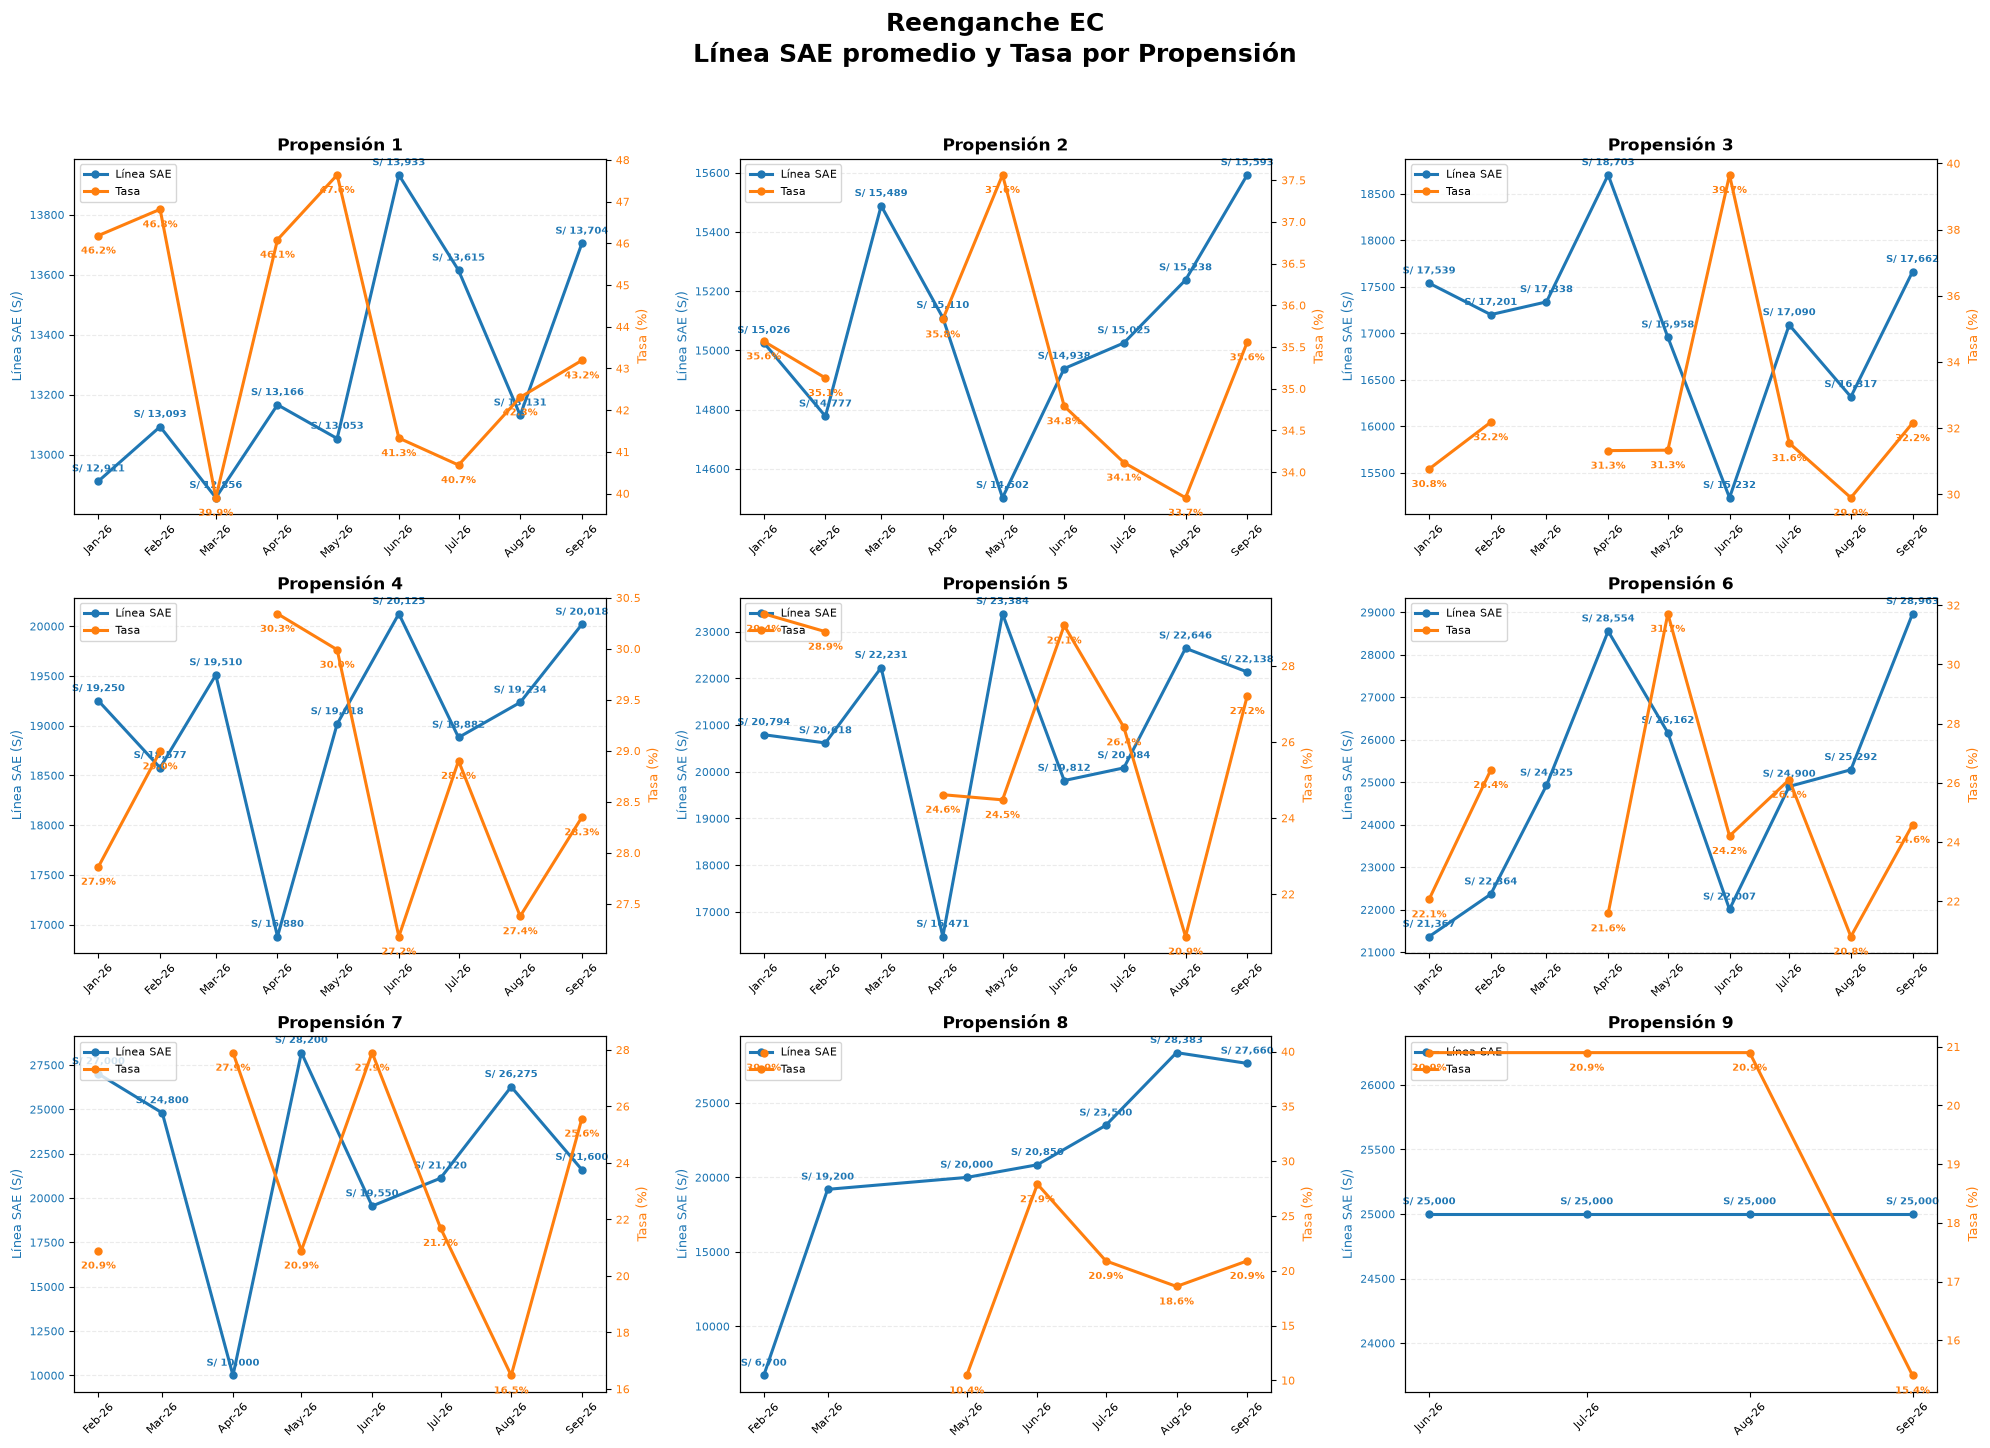

In [ ]:
# ============================================================
# MATRIZ 4 X 3
# ============================================================
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(20, 18)
)

axes = axes.flatten()

for i, propension in enumerate(orden_propension):

    ax1 = axes[i]

    df_prop = (
        df_mensual_propension[
            df_mensual_propension["PROPENSION"] == propension
        ]
        .sort_values("mes")
        .copy()
    )

    if df_prop.empty:
        ax1.set_visible(False)
        continue

    # Línea SAE
    linea1, = ax1.plot(
        df_prop["mes"],
        df_prop["linea_sae_promedio"],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color="#1f77b4",
        label="Línea SAE"
    )

    for mes, valor in zip(
        df_prop["mes"],
        df_prop["linea_sae_promedio"]
    ):
        ax1.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=7,
            color="#1f77b4",
            fontweight="bold"
        )

    ax1.set_ylabel(
        "Línea SAE (S/)",
        color="#1f77b4",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#1f77b4",
        labelsize=8
    )

    # Tasa
    ax2 = ax1.twinx()

    linea2, = ax2.plot(
        df_prop["mes"],
        df_prop["tasa"],
        marker="o",
        linewidth=2.2,
        markersize=5,
        color="#ff7f0e",
        label="Tasa"
    )

    for mes, valor in zip(
        df_prop["mes"],
        df_prop["tasa"]
    ):
        ax2.annotate(
            f"{valor:.1f}%",
            xy=(mes, valor),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            fontsize=7,
            color="#ff7f0e",
            fontweight="bold"
        )

    ax2.set_ylabel(
        "Tasa (%)",
        color="#ff7f0e",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#ff7f0e",
        labelsize=8
    )

    ax1.set_title(
        f"Propensión {propension}",
        fontsize=12,
        fontweight="bold"
    )

    ax1.set_xticks(df_prop["mes"])

    ax1.set_xticklabels(
        [
            fecha.strftime("%b-%y")
            for fecha in df_prop["mes"]
        ],
        rotation=45,
        fontsize=8
    )

    ax1.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax1.legend(
        [linea1, linea2],
        ["Línea SAE", "Tasa"],
        loc="upper left",
        fontsize=8
    )

# Ocultar espacios sobrantes
for j in range(len(orden_propension), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"{producto_seleccionado}\n"
    "Línea SAE promedio y Tasa por Propensión",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

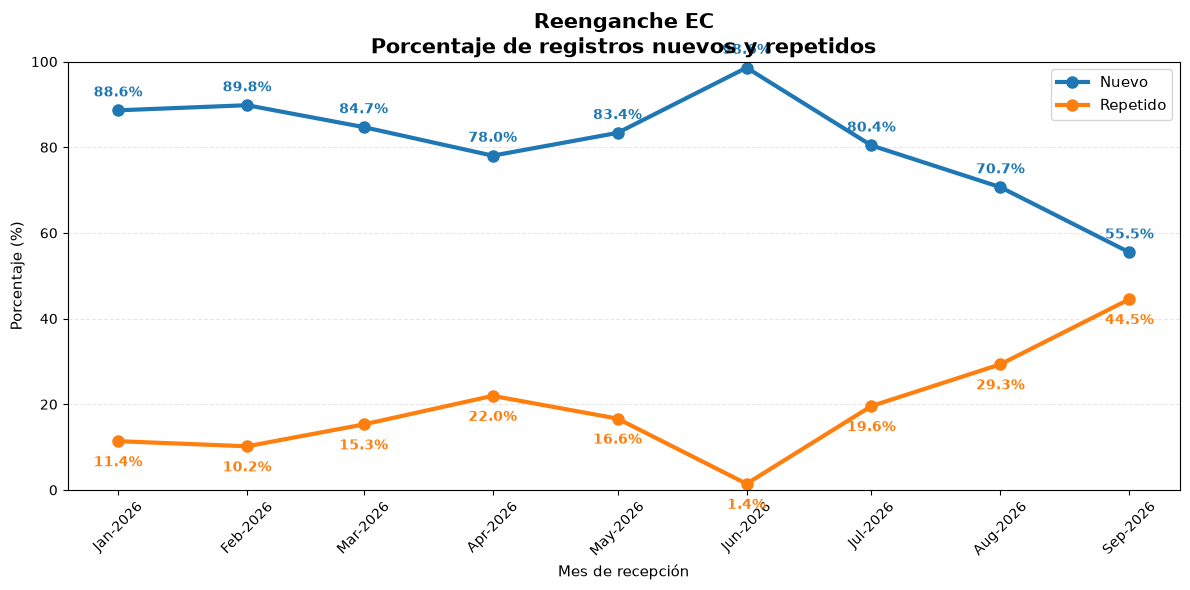

Tipo,Nuevo,Repetido,Total,Porcentaje_nuevo,Porcentaje_repetido
mes,,,,,
2026-01-01,1114,143,1257,88.62,11.38
2026-02-01,1632,185,1817,89.82,10.18
2026-03-01,1496,270,1766,84.71,15.29
2026-04-01,1201,338,1539,78.04,21.96
2026-05-01,1212,242,1454,83.36,16.64
2026-06-01,2071,30,2101,98.57,1.43
2026-07-01,1545,376,1921,80.43,19.57
2026-08-01,2610,1083,3693,70.67,29.33
2026-09-01,1087,873,1960,55.46,44.54


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PRODUCTO A ANALIZAR
# ============================================================
producto_seleccionado = "Reenganche EC"   # Cambiar por AEC, AER, CD, etc.

# ============================================================
# FILTRAR PRODUCTO
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Asegurar tipos
df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])
df_grafico["diferencia"] = pd.to_numeric(df_grafico["diferencia"], errors="coerce")
df_grafico["cantidad"] = pd.to_numeric(df_grafico["cantidad"], errors="coerce").fillna(0)

# ============================================================
# NUEVO O REPETIDO
# ============================================================
df_grafico["Tipo"] = df_grafico["diferencia"].apply(
    lambda x: "Nuevo" if x == 0 else "Repetido"
)

# ============================================================
# RESUMEN MENSUAL
# ============================================================
df_resumen_grafico = (
    df_grafico
    .groupby(["mes", "Tipo"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# En caso de que falte alguna columna
for col in ["Nuevo", "Repetido"]:
    if col not in df_resumen_grafico.columns:
        df_resumen_grafico[col] = 0

df_resumen_grafico["Total"] = (
    df_resumen_grafico["Nuevo"] +
    df_resumen_grafico["Repetido"]
)

df_resumen_grafico["Porcentaje_nuevo"] = (
    df_resumen_grafico["Nuevo"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico["Porcentaje_repetido"] = (
    df_resumen_grafico["Repetido"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico = df_resumen_grafico.sort_index()

# ============================================================
# GRAFICO
# ============================================================
plt.figure(figsize=(12,6))

# Línea azul
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4",
    label="Nuevo"
)

# Línea naranja
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#ff7f0e",
    label="Repetido"
)

# ============================================================
# ETIQUETAS NUEVO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        color="#1f77b4",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# ETIQUETAS REPETIDO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        color="#ff7f0e",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado}\nPorcentaje de registros nuevos y repetidos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Porcentaje (%)", fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.xticks(
    df_resumen_grafico.index,
    [d.strftime("%b-%Y") for d in df_resumen_grafico.index],
    rotation=45
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_resumen_grafico[
        [
            "Nuevo",
            "Repetido",
            "Total",
            "Porcentaje_nuevo",
            "Porcentaje_repetido"
        ]
    ].round(2)
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

producto = "Reenganche EC"

df = df_filtrado[df_filtrado["producto"] == producto].copy()

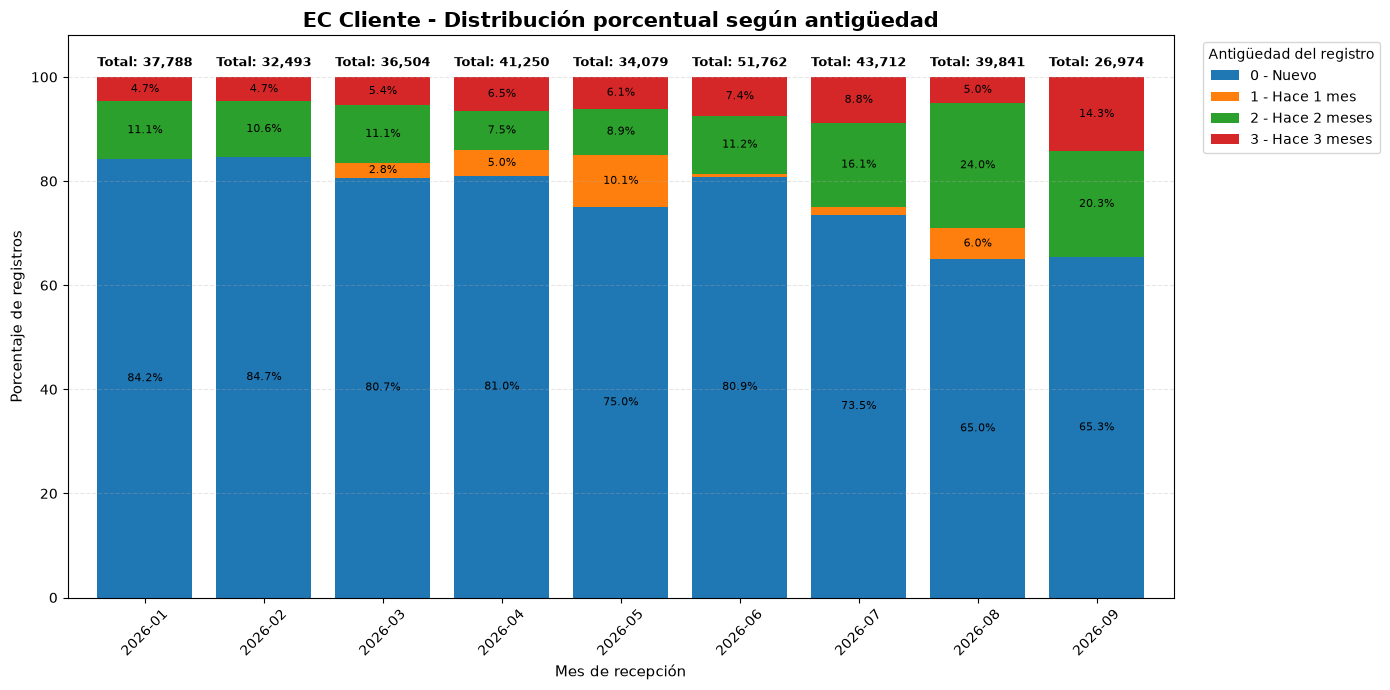

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,84.21%,0.00%,11.09%,4.69%,37788
2026-02-01,84.66%,0.00%,10.63%,4.70%,32493
2026-03-01,80.67%,2.83%,11.06%,5.44%,36504
2026-04-01,80.99%,4.99%,7.49%,6.53%,41250
2026-05-01,74.98%,10.08%,8.85%,6.09%,34079
2026-06-01,80.87%,0.52%,11.17%,7.43%,51762
2026-07-01,73.54%,1.55%,16.09%,8.82%,43712
2026-08-01,64.96%,6.04%,24.03%,4.97%,39841
2026-09-01,65.34%,0.11%,20.29%,14.26%,26974


## otros

In [26]:
df_filtrado.head()

,producto,mes,PROPENSION,diferencia,cantidad,tea_count,tea_sum,linea_sae_count,linea_sae_sum,ref
0,AEC,2026-01-01,None,0,1561,1561,1369.8839,1561,6825965.0,2026-01-01
1,AEC,2026-01-01,None,2,59,59,51.7815,59,283118.0,2025-11-01
2,AER,2026-01-01,None,0,3208,3208,2816.4379,3208,9159627.0,2026-01-01
3,AER,2026-01-01,None,2,112,112,98.4165,112,326392.0,2025-11-01
4,CD,2026-01-01,1,0,285,285,54.3850,285,4641000.0,2026-01-01


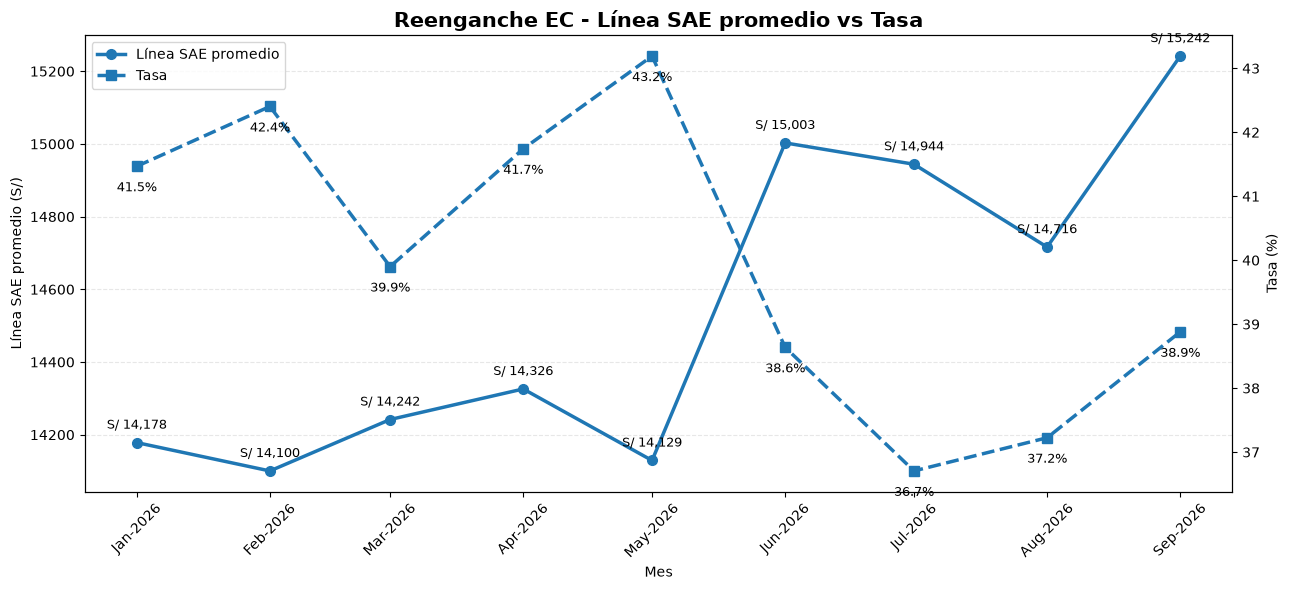

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PRODUCTO A ANALIZAR
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# 1. FILTRAR PRODUCTO
# ============================================================
df_plot = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_plot["mes"] = pd.to_datetime(
    df_plot["mes"],
    errors="coerce"
)

# ============================================================
# 2. AGRUPAR POR MES
# ============================================================
df_mensual = (
    df_plot
    .groupby("mes", as_index=False)
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
    .sort_values("mes")
)

# ============================================================
# 3. CALCULAR INDICADORES
# ============================================================

# Línea SAE promedio
df_mensual["linea_sae_promedio"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Tasa
df_mensual["tasa"] = (
    df_mensual["tea_sum"]
    / df_mensual["tea_count"]
) * 100

# ============================================================
# 4. GRÁFICO
# ============================================================
fig, ax1 = plt.subplots(figsize=(13, 6))

# ------------------------------------------------------------
# LÍNEA SAE
# ------------------------------------------------------------
linea1, = ax1.plot(
    df_mensual["mes"],
    df_mensual["linea_sae_promedio"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Línea SAE promedio"
)

# Etiquetas Línea SAE
for mes, valor in zip(
    df_mensual["mes"],
    df_mensual["linea_sae_promedio"]
):
    ax1.annotate(
        f"S/ {valor:,.0f}",
        xy=(mes, valor),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax1.set_ylabel("Línea SAE promedio (S/)")
ax1.set_xlabel("Mes")

# ============================================================
# SEGUNDO EJE: TASA
# ============================================================
ax2 = ax1.twinx()

linea2, = ax2.plot(
    df_mensual["mes"],
    df_mensual["tasa"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    linestyle="--",
    label="Tasa"
)

# Etiquetas Tasa
for mes, valor in zip(
    df_mensual["mes"],
    df_mensual["tasa"]
):
    ax2.annotate(
        f"{valor:.1f}%",
        xy=(mes, valor),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax2.set_ylabel("Tasa (%)")

# ============================================================
# FORMATO DEL EJE X
# ============================================================
ax1.set_xticks(df_mensual["mes"])

ax1.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_mensual["mes"]
    ],
    rotation=45
)

# ============================================================
# TÍTULO
# ============================================================
ax1.set_title(
    f"{producto_seleccionado} - Línea SAE promedio vs Tasa",
    fontsize=15,
    fontweight="bold"
)

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# ============================================================
# LEYENDA
# ============================================================
lineas = [linea1, linea2]

ax1.legend(
    lineas,
    [l.get_label() for l in lineas],
    loc="upper left"
)

plt.tight_layout()
plt.show()

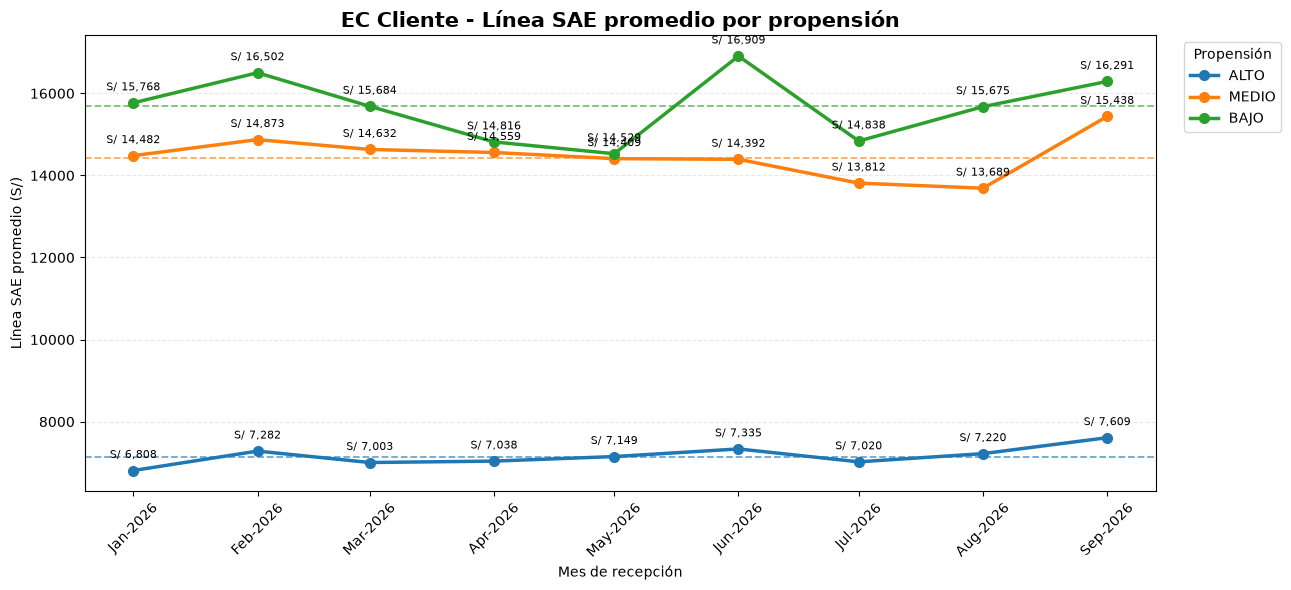

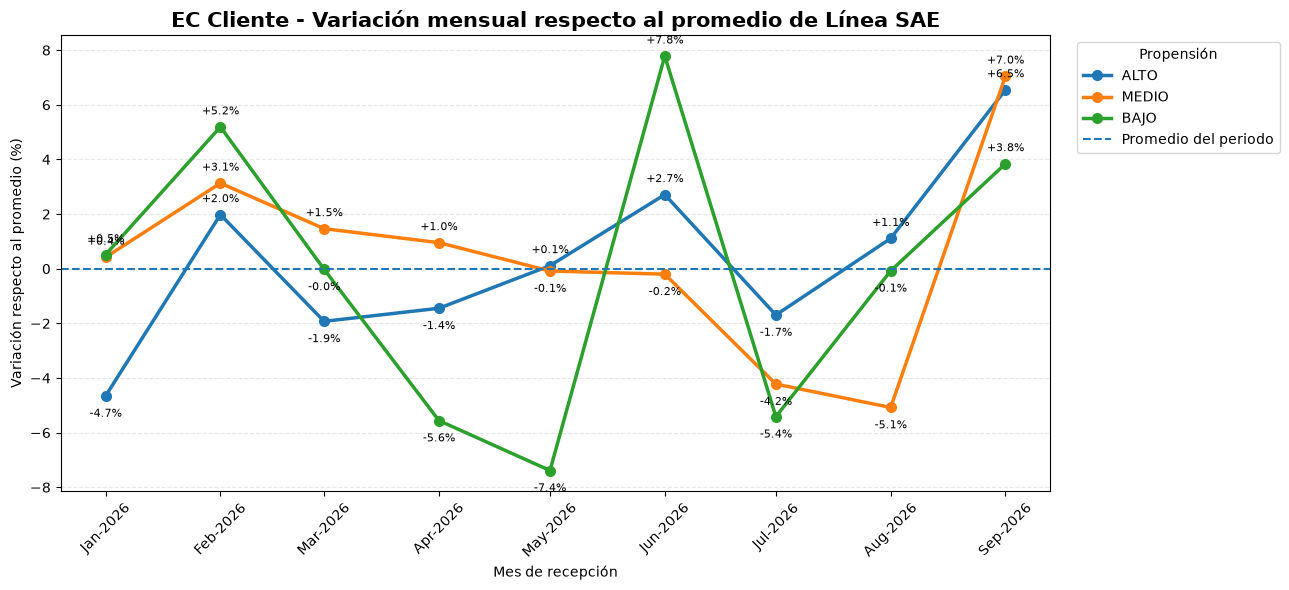

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,ALTO,"S/ 7,140.94","S/ 6,808.43","S/ 7,608.65",S/ 232.68,3.26%,11.21%,Muy estable
1,MEDIO,"S/ 14,421.10","S/ 13,688.63","S/ 15,437.75",S/ 522.71,3.62%,12.13%,Muy estable
2,BAJO,"S/ 15,687.64","S/ 14,528.82","S/ 16,908.71",S/ 817.45,5.21%,15.17%,Estable


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden deseado
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

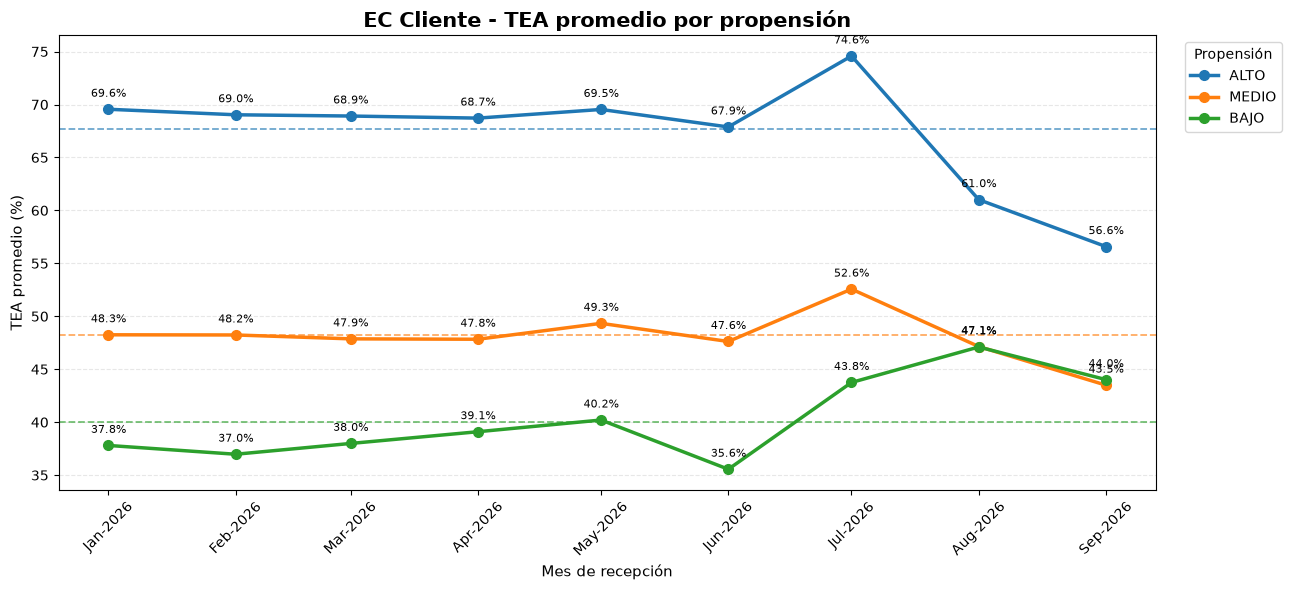

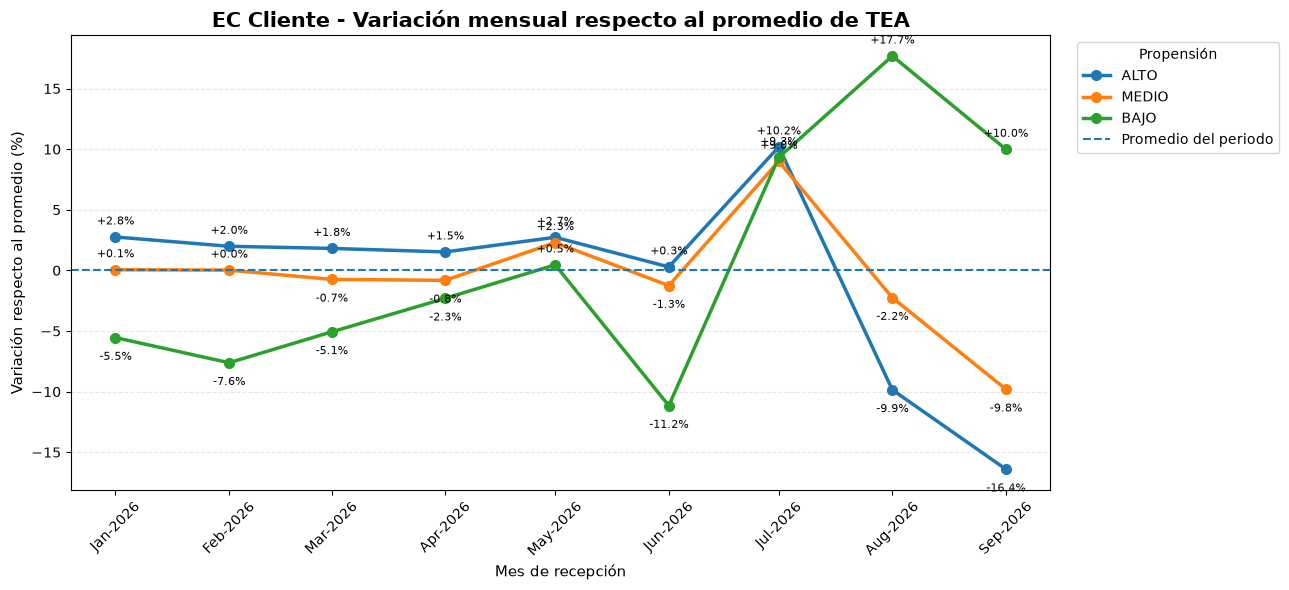

,Propensión,TEA promedio del periodo,TEA mínima mensual,TEA máxima mensual,Desviación estándar,Coeficiente de variación,Rango en puntos porcentuales,Nivel de estabilidad
0,ALTO,67.68%,56.58%,74.58%,5.31%,7.84%,18.00%,Estable
1,MEDIO,48.23%,43.50%,52.57%,2.34%,4.86%,9.07%,Muy estable
2,BAJO,40.02%,35.56%,47.10%,3.85%,9.62%,11.54%,Estable


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden de los segmentos
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["tea_sum"] = pd.to_numeric(
    df_grafico["tea_sum"],
    errors="coerce"
).fillna(0)

df_grafico["tea_count"] = pd.to_numeric(
    df_grafico["tea_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solo ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin datos válidos de TEA
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["tea_count"] > 0)
].copy()

# ============================================================
# 2. CALCULAR TEA PROMEDIO PONDERADA POR MES Y PROPENSIÓN
# ============================================================
df_tea_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# La TEA original está expresada como decimal:
# 0.6955 = 69.55 %
df_tea_mensual["Promedio_TEA"] = (
    df_tea_mensual["tea_sum"]
    / df_tea_mensual["tea_count"]
    * 100
)

# Formato ancho
df_tea = (
    df_tea_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
    .sort_index()
)

columnas_existentes = [
    propension
    for propension in orden_propension
    if propension in df_tea.columns
]

df_tea = df_tea[columnas_existentes]

# ============================================================
# 3. TEA PROMEDIO PONDERADA DEL PERIODO POR PROPENSIÓN
# ============================================================
df_tea_periodo = (
    df_grafico
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

df_tea_periodo["Promedio_periodo"] = (
    df_tea_periodo["tea_sum"]
    / df_tea_periodo["tea_count"]
    * 100
)

promedios_periodo = (
    df_tea_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN DE LA TEA PROMEDIO POR PROPENSIÓN
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_tea.index,
        df_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Etiquetas mensuales
    for mes, valor in df_tea[propension].dropna().items():
        ax.annotate(
            f"{valor:.1f}%",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Línea punteada: promedio del periodo
    promedio = promedios_periodo.get(propension)

    if promedio is not None and pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - TEA promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "TEA promedio (%)",
    fontsize=11
)

ax.set_xticks(df_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. VARIACIÓN MENSUAL RESPECTO AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion_tea = df_tea.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion_tea[propension] = (
        (
            df_tea[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN DE LA TEA RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion_tea.index,
        df_variacion_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion_tea[propension].dropna().items():

        desplazamiento = 9 if valor >= 0 else -16

        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, desplazamiento),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Referencia central
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de TEA",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "Variación respecto al promedio (%)",
    fontsize=11
)

ax.set_xticks(df_variacion_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA DE ESTABILIDAD DE LA TEA
# ============================================================
resumen_estabilidad_tea = []

for propension in columnas_existentes:

    valores = df_tea[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_puntos_porcentuales = maximo - minimo

    resumen_estabilidad_tea.append({
        "Propensión": propension,
        "TEA promedio del periodo": promedio,
        "TEA mínima mensual": minimo,
        "TEA máxima mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango en puntos porcentuales": rango_puntos_porcentuales
    })

df_resumen_tea = pd.DataFrame(
    resumen_estabilidad_tea
)

# Clasificación orientativa
df_resumen_tea["Nivel de estabilidad"] = (
    df_resumen_tea["Coeficiente de variación"]
    .apply(
        lambda valor: (
            "Muy estable"
            if valor < 5
            else "Estable"
            if valor < 10
            else "Variable"
        )
    )
)

# ============================================================
# 8. FORMATO DE LA TABLA FINAL
# ============================================================
df_tabla_tea = df_resumen_tea.copy()

for columna in [
    "TEA promedio del periodo",
    "TEA mínima mensual",
    "TEA máxima mensual",
    "Desviación estándar",
    "Coeficiente de variación",
    "Rango en puntos porcentuales"
]:
    df_tabla_tea[columna] = (
        df_tabla_tea[columna]
        .map(lambda valor: f"{valor:.2f}%")
    )

display(df_tabla_tea)

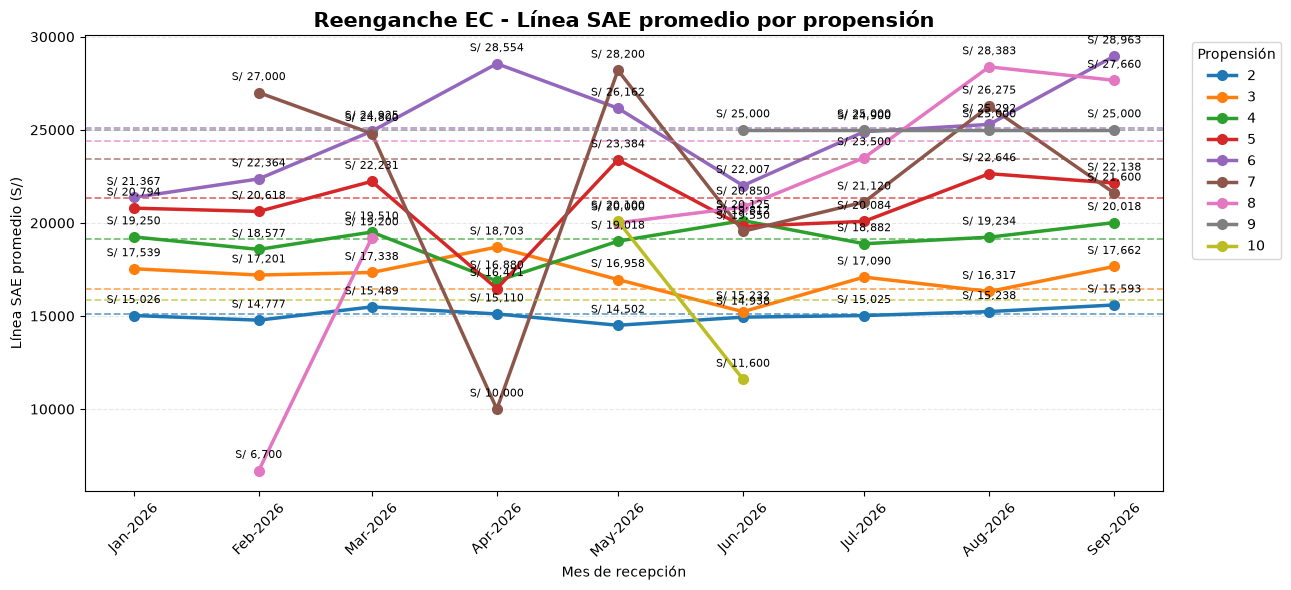

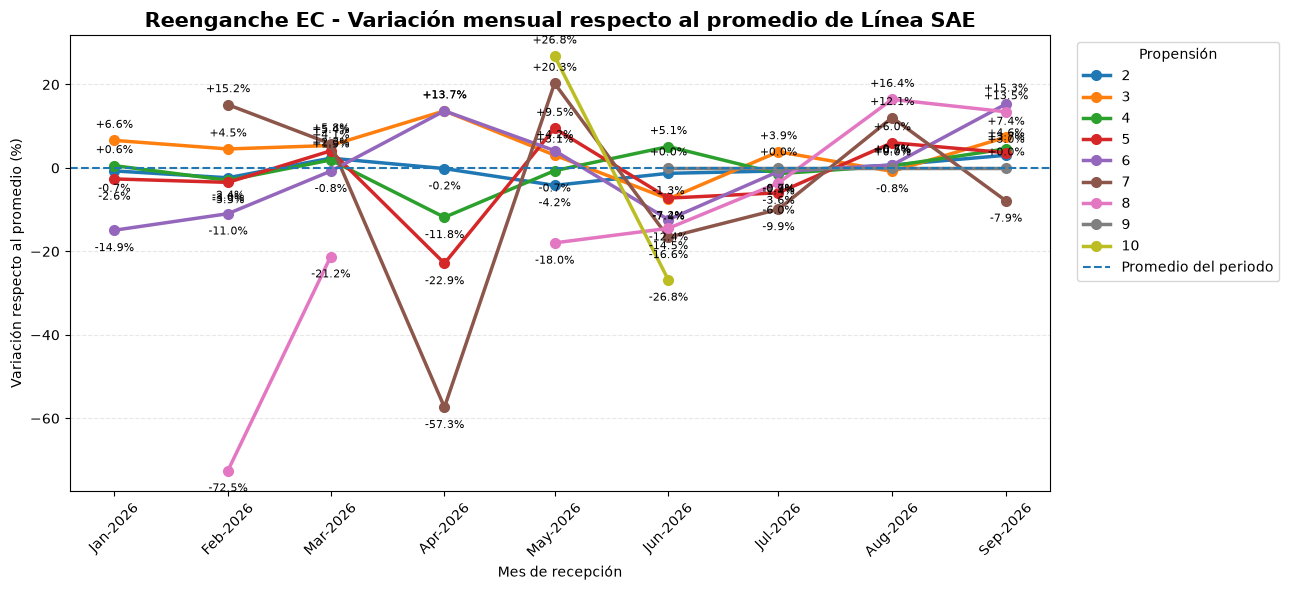

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,2,"S/ 15,133.61","S/ 14,502.13","S/ 15,592.67",S/ 336.72,2.23%,7.21%,Muy estable
1,3,"S/ 16,452.23","S/ 15,231.94","S/ 18,703.12",S/ 953.07,5.79%,21.10%,Estable
2,4,"S/ 19,144.31","S/ 16,880.33","S/ 20,125.30",S/ 957.87,5.00%,16.95%,Estable
3,5,"S/ 21,356.16","S/ 16,471.43","S/ 23,384.21","S/ 2,063.81",9.66%,32.37%,Estable
4,6,"S/ 25,117.93","S/ 21,366.67","S/ 28,963.16","S/ 2,712.70",10.80%,30.24%,Variable
5,7,"S/ 23,445.83","S/ 10,000.00","S/ 28,200.00","S/ 5,851.53",24.96%,77.63%,Variable
6,8,"S/ 24,378.95","S/ 6,700.00","S/ 28,383.33","S/ 7,231.88",29.66%,88.94%,Variable
7,9,"S/ 25,000.00","S/ 25,000.00","S/ 25,000.00",S/ 0.00,0.00%,0.00%,Muy estable
8,10,"S/ 15,850.00","S/ 11,600.00","S/ 20,100.00","S/ 6,010.41",37.92%,53.63%,Variable


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"
# producto_seleccionado = "EC Cliente"
# Orden deseado
orden_propension = ["'1'", "2", "3",'4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

In [28]:
import pandas as pd
import numpy as np

df_analisis = df_filtrado[
    df_filtrado["producto"] == "EC Cliente"
].copy()

# ============================================================
# 1. LIMPIEZA
# ============================================================

df_analisis["mes"] = pd.to_datetime(
    df_analisis["mes"],
    errors="coerce"
)

df_analisis["PROPENSION"] = (
    df_analisis["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_analisis["linea_sae_sum"] = pd.to_numeric(
    df_analisis["linea_sae_sum"],
    errors="coerce"
)

df_analisis["linea_sae_count"] = pd.to_numeric(
    df_analisis["linea_sae_count"],
    errors="coerce"
)

df_analisis = df_analisis[
    df_analisis["PROPENSION"].isin(["ALTO", "MEDIO", "BAJO"])
    & (df_analisis["linea_sae_count"] > 0)
].copy()


# ============================================================
# 2. LINEA SAE PROMEDIO
# ============================================================

df_analisis["LINEA_SAE_PROMEDIO"] = (
    df_analisis["linea_sae_sum"]
    / df_analisis["linea_sae_count"]
)


# ============================================================
# 3. CREAR RANGOS DE LINEA
#    Puedes cambiar estos cortes según negocio
# ============================================================

bins = [
    0,
    5000,
    10000,
    15000,
    20000,
    np.inf
]

labels = [
    "01. Hasta S/ 5K",
    "02. S/ 5K - 10K",
    "03. S/ 10K - 15K",
    "04. S/ 15K - 20K",
    "05. Más de S/ 20K"
]

df_analisis["RANGO_LINEA"] = pd.cut(
    df_analisis["LINEA_SAE_PROMEDIO"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)


# ============================================================
# 4. MATRIZ PROPENSION x RANGO DE LINEA
# ============================================================

tabla = pd.crosstab(
    df_analisis["PROPENSION"],
    df_analisis["RANGO_LINEA"],
    values=df_analisis["linea_sae_count"],
    aggfunc="sum"
).fillna(0)

tabla = tabla.reindex(
    ["ALTO", "MEDIO", "BAJO"]
)

display(tabla)

RANGO_LINEA,01. Hasta S/ 5K,02. S/ 5K - 10K,03. S/ 10K - 15K,04. S/ 15K - 20K,05. Más de S/ 20K
PROPENSION,,,,,
ALTO,0,49683,0,12,0
MEDIO,0,0,111307,19868,1
BAJO,0,0,53543,109974,0


In [29]:
import pandas as pd

# ============================================================
# ANÁLISIS MENSUAL: PROPENSIÓN + LÍNEA SAE
# ============================================================

producto_seleccionado = "EC Cliente"

df_mes_propension = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# ------------------------------------------------------------
# 1. LIMPIEZA
# ------------------------------------------------------------

df_mes_propension["mes"] = pd.to_datetime(
    df_mes_propension["mes"],
    errors="coerce"
)

df_mes_propension["PROPENSION"] = (
    df_mes_propension["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_mes_propension["linea_sae_sum"] = pd.to_numeric(
    df_mes_propension["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_mes_propension["linea_sae_count"] = pd.to_numeric(
    df_mes_propension["linea_sae_count"],
    errors="coerce"
).fillna(0)

# Solo las 3 propensiones
df_mes_propension = df_mes_propension[
    df_mes_propension["PROPENSION"].isin(
        ["ALTO", "MEDIO", "BAJO"]
    )
].copy()


# ------------------------------------------------------------
# 2. AGRUPAR POR MES + PROPENSIÓN
# ------------------------------------------------------------

tabla_mensual = (
    df_mes_propension
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        CLIENTES=("linea_sae_count", "sum"),
        LINEA_SAE_TOTAL=("linea_sae_sum", "sum")
    )
)


# ------------------------------------------------------------
# 3. LÍNEA SAE PROMEDIO
# ------------------------------------------------------------

tabla_mensual["LINEA_SAE_PROMEDIO"] = (
    tabla_mensual["LINEA_SAE_TOTAL"]
    / tabla_mensual["CLIENTES"]
)


# ------------------------------------------------------------
# 4. PARTICIPACIÓN DE CADA PROPENSIÓN EN EL MES
# ------------------------------------------------------------

tabla_mensual["TOTAL_MES"] = (
    tabla_mensual
    .groupby("mes")["CLIENTES"]
    .transform("sum")
)

tabla_mensual["PARTICIPACION"] = (
    tabla_mensual["CLIENTES"]
    / tabla_mensual["TOTAL_MES"]
    * 100
)


# ------------------------------------------------------------
# 5. ORDENAR
# ------------------------------------------------------------

orden_propension = ["ALTO", "MEDIO", "BAJO"]

tabla_mensual["PROPENSION"] = pd.Categorical(
    tabla_mensual["PROPENSION"],
    categories=orden_propension,
    ordered=True
)

tabla_mensual = tabla_mensual.sort_values(
    ["mes", "PROPENSION"]
)


# ------------------------------------------------------------
# 6. FORMATO PARA MOSTRAR
# ------------------------------------------------------------

tabla_mostrar = tabla_mensual[
    [
        "mes",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
].copy()

tabla_mostrar["MES"] = (
    tabla_mostrar["mes"]
    .dt.strftime("%Y-%m")
)

tabla_mostrar["PARTICIPACION"] = (
    tabla_mostrar["PARTICIPACION"]
    .map(lambda x: f"{x:.1f}%")
)

tabla_mostrar["LINEA_SAE_PROMEDIO"] = (
    tabla_mostrar["LINEA_SAE_PROMEDIO"]
    .map(lambda x: f"S/ {x:,.0f}")
)

tabla_mostrar = tabla_mostrar[
    [
        "MES",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
]

display(tabla_mostrar)

,MES,PROPENSION,CLIENTES,PARTICIPACION,LINEA_SAE_PROMEDIO
0,2026-01,ALTO,5958,15.8%,"S/ 6,808"
2,2026-01,MEDIO,14597,38.6%,"S/ 14,482"
1,2026-01,BAJO,17233,45.6%,"S/ 15,768"
3,2026-02,ALTO,5555,17.1%,"S/ 7,282"
5,2026-02,MEDIO,12609,38.8%,"S/ 14,873"
4,2026-02,BAJO,14329,44.1%,"S/ 16,502"
6,2026-03,ALTO,5170,14.2%,"S/ 7,003"
8,2026-03,MEDIO,14242,39.0%,"S/ 14,632"
7,2026-03,BAJO,17092,46.8%,"S/ 15,684"
9,2026-04,ALTO,6069,14.7%,"S/ 7,038"


In [30]:
# ============================================================
# COMPARACIÓN AGOSTO VS SEPTIEMBRE
# ============================================================

comparacion = tabla_mensual[
    tabla_mensual["mes"].dt.to_period("M").isin(
        [
            pd.Period("2026-08"),
            pd.Period("2026-09")
        ]
    )
].copy()

comparacion["MES"] = (
    comparacion["mes"]
    .dt.strftime("%Y-%m")
)

comparacion = comparacion[
    [
        "MES",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
]

display(comparacion)

,MES,PROPENSION,CLIENTES,PARTICIPACION,LINEA_SAE_PROMEDIO
21,2026-08,ALTO,7047,17.690029,7220.051086
23,2026-08,MEDIO,15387,38.625866,13688.633262
22,2026-08,BAJO,17402,43.684105,15675.278704
24,2026-09,ALTO,3248,12.041225,7608.651478
26,2026-09,MEDIO,10403,38.566768,15437.748726
25,2026-09,BAJO,13323,49.392007,16290.625235


In [ ]:
df_filtrado = df_resumen.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'cenvo_repitencia.xlsx')

df_filtrado.to_excel(ruta_archivo, index=False)


In [61]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# Orden de presentación
orden_propension = ['1','2','3','4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Convertir mes
df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

# Convertir columnas numéricas
columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Limpiar propensión
df_tabla["PROPENSION"] = (
    df_tabla["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solamente ALTO, MEDIO y BAJO
df_tabla = df_tabla[
    df_tabla["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar filas sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR POR MES Y PROPENSIÓN
# ============================================================
df_resumen = (
    df_tabla
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen["Promedio_linea_sae"] = np.where(
    df_resumen["linea_sae_count"] > 0,
    df_resumen["linea_sae_sum"]
    / df_resumen["linea_sae_count"],
    np.nan
)

# La TEA está almacenada como decimal:
# 0.6955 equivale a 69.55 %
df_resumen["Promedio_TEA"] = np.where(
    df_resumen["tea_count"] > 0,
    (
        df_resumen["tea_sum"]
        / df_resumen["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. TOTAL DE LA BASE POR MES
# ============================================================
df_total_mes = (
    df_resumen
    .groupby("mes", as_index=False)["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad": "Total Base"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total_mes,
    on="mes",
    how="left"
)

# Participación de cada propensión dentro del mes
df_resumen["Participacion"] = np.where(
    df_resumen["Total Base"] > 0,
    (
        df_resumen["cantidad"]
        / df_resumen["Total Base"]
    ) * 100,
    0
)

# ============================================================
# 5. CREAR TABLAS PIVOT
# ============================================================

# Participación porcentual
tabla_participacion = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Participacion"
    )
)

# Línea SAE promedio
tabla_linea_sae = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
)

# TEA promedio
tabla_tea = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
)

# Cantidad por propensión
tabla_cantidad = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
)

# Asegurar que las columnas estén en orden
for propension in orden_propension:

    if propension not in tabla_participacion.columns:
        tabla_participacion[propension] = 0

    if propension not in tabla_linea_sae.columns:
        tabla_linea_sae[propension] = np.nan

    if propension not in tabla_tea.columns:
        tabla_tea[propension] = np.nan

    if propension not in tabla_cantidad.columns:
        tabla_cantidad[propension] = 0

tabla_participacion = tabla_participacion[orden_propension]
tabla_linea_sae = tabla_linea_sae[orden_propension]
tabla_tea = tabla_tea[orden_propension]
tabla_cantidad = tabla_cantidad[orden_propension]

# ============================================================
# 6. ARMAR TABLA FINAL
# ============================================================
df_tabla_final = pd.DataFrame(
    index=tabla_participacion.index
)

# Total mensual
df_tabla_final["Total Base"] = (
    tabla_cantidad.sum(axis=1)
)

# Columnas por propensión
for propension in orden_propension:

    df_tabla_final[
        f"% {propension}"
    ] = tabla_participacion[propension]

    df_tabla_final[
        f"Línea SAE {propension}"
    ] = tabla_linea_sae[propension]

    df_tabla_final[
        f"TEA {propension}"
    ] = tabla_tea[propension]

# ============================================================
# 7. FILA CONSOLIDADA DEL PERIODO
# ============================================================
df_periodo = (
    df_tabla
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

total_periodo = df_periodo["cantidad"].sum()

fila_periodo = {
    "Total Base": total_periodo
}

for propension in orden_propension:

    datos = df_periodo[
        df_periodo["PROPENSION"] == propension
    ]

    if not datos.empty:

        cantidad_propension = datos["cantidad"].iloc[0]

        participacion = (
            cantidad_propension / total_periodo * 100
            if total_periodo > 0
            else 0
        )

        promedio_linea = (
            datos["linea_sae_sum"].iloc[0]
            / datos["linea_sae_count"].iloc[0]
            if datos["linea_sae_count"].iloc[0] > 0
            else np.nan
        )

        promedio_tea = (
            datos["tea_sum"].iloc[0]
            / datos["tea_count"].iloc[0]
            * 100
            if datos["tea_count"].iloc[0] > 0
            else np.nan
        )

    else:

        participacion = 0
        promedio_linea = np.nan
        promedio_tea = np.nan

    fila_periodo[f"% {propension}"] = participacion
    fila_periodo[f"Línea SAE {propension}"] = promedio_linea
    fila_periodo[f"TEA {propension}"] = promedio_tea

# Cambiar el índice mensual a texto
df_tabla_final.index = [
    fecha.strftime("%B %Y").capitalize()
    for fecha in df_tabla_final.index
]

# Agregar fila consolidada
df_tabla_final.loc["TOTAL PERIODO"] = fila_periodo

# ============================================================
# 8. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

# Total base como entero con separador de miles
df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

for propension in orden_propension:

    # Participación
    df_tabla_mostrar[f"% {propension}"] = (
        df_tabla_mostrar[f"% {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

    # Línea SAE
    df_tabla_mostrar[f"Línea SAE {propension}"] = (
        df_tabla_mostrar[f"Línea SAE {propension}"]
        .map(
            lambda valor:
            f"S/ {valor:,.2f}"
            if pd.notna(valor)
            else "-"
        )
    )

    # TEA
    df_tabla_mostrar[f"TEA {propension}"] = (
        df_tabla_mostrar[f"TEA {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

# Nombre del índice
df_tabla_mostrar.index.name = "Mes de recepción"

# ============================================================
# 9. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Total Base,% 1,Línea SAE 1,TEA 1,% 2,Línea SAE 2,TEA 2,% 3,Línea SAE 3,TEA 3,...,TEA 7,% 8,Línea SAE 8,TEA 8,% 9,Línea SAE 9,TEA 9,% 10,Línea SAE 10,TEA 10
Mes de recepción,,,,,,,,,,,,,,,,,,,,,
January 2026,"1,257",64.04%,"S/ 12,911.30",46.19%,22.04%,"S/ 15,025.63",35.57%,7.16%,"S/ 17,538.89",30.77%,...,-,-,-,-,-,-,-,-,-,-
February 2026,"1,817",67.47%,"S/ 13,092.90",46.82%,18.82%,"S/ 14,777.19",35.13%,7.82%,"S/ 17,200.70",32.18%,...,20.90%,0.06%,"S/ 6,700.00",39.90%,-,-,-,-,-,-
March 2026,"1,766",65.18%,"S/ 12,855.87",39.90%,21.18%,"S/ 15,488.50",-,7.47%,"S/ 17,337.88",-,...,-,0.06%,"S/ 19,200.00",-,-,-,-,-,-,-
April 2026,"1,539",65.63%,"S/ 13,165.94",46.09%,20.27%,"S/ 15,110.26",35.83%,8.32%,"S/ 18,703.12",31.32%,...,27.90%,-,-,-,-,-,-,-,-,-
May 2026,"1,454",66.51%,"S/ 13,053.36",47.64%,19.39%,"S/ 14,502.13",37.56%,7.63%,"S/ 16,957.66",31.34%,...,20.90%,0.14%,"S/ 20,000.00",10.45%,-,-,-,0.07%,"S/ 20,100.00",20.90%
June 2026,"2,101",38.32%,"S/ 13,932.92",41.33%,17.71%,"S/ 14,938.44",34.79%,37.55%,"S/ 15,231.94",39.65%,...,27.90%,0.10%,"S/ 20,850.00",27.90%,0.05%,"S/ 25,000.00",20.90%,0.05%,"S/ 11,600.00",20.90%
July 2026,"1,921",52.42%,"S/ 13,614.70",40.68%,27.49%,"S/ 15,025.00",34.11%,11.19%,"S/ 17,090.23",31.55%,...,21.70%,0.10%,"S/ 23,500.00",20.90%,0.05%,"S/ 25,000.00",20.90%,-,-,-
August 2026,"1,509",56.20%,"S/ 12,739.74",43.74%,26.64%,"S/ 15,197.76",34.66%,9.21%,"S/ 16,226.62",30.68%,...,14.45%,-,-,-,-,-,-,-,-,-
TOTAL PERIODO,"13,364",58.51%,"S/ 13,159.24",44.77%,21.62%,"S/ 15,026.79",35.20%,13.06%,"S/ 16,342.38",35.42%,...,21.30%,0.06%,"S/ 19,325.00",22.63%,0.01%,"S/ 25,000.00",20.90%,0.01%,"S/ 15,850.00",20.90%


In [62]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Eliminar registros sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR SOLAMENTE POR MES
# No se considera PROPENSION
# ============================================================
df_resumen_mensual = (
    df_tabla
    .groupby(
        "mes",
        as_index=False
    )
    .agg(
        total_base=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
    .sort_values("mes")
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen_mensual["Promedio Línea SAE"] = np.where(
    df_resumen_mensual["linea_sae_count"] > 0,
    (
        df_resumen_mensual["linea_sae_sum"]
        / df_resumen_mensual["linea_sae_count"]
    ),
    np.nan
)

# TEA almacenada como decimal:
# 0.50 equivale a 50 %
df_resumen_mensual["Promedio TEA"] = np.where(
    df_resumen_mensual["tea_count"] > 0,
    (
        df_resumen_mensual["tea_sum"]
        / df_resumen_mensual["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. SELECCIONAR COLUMNAS FINALES
# ============================================================
df_tabla_final = df_resumen_mensual[
    [
        "mes",
        "total_base",
        "Promedio Línea SAE",
        "Promedio TEA"
    ]
].copy()

df_tabla_final = df_tabla_final.rename(
    columns={
        "mes": "Mes de recepción",
        "total_base": "Total Base"
    }
)

# ============================================================
# 5. FILA TOTAL DEL PERIODO
# ============================================================
total_base_periodo = df_tabla["cantidad"].sum()

total_linea_sum = df_tabla["linea_sae_sum"].sum()
total_linea_count = df_tabla["linea_sae_count"].sum()

total_tea_sum = df_tabla["tea_sum"].sum()
total_tea_count = df_tabla["tea_count"].sum()

promedio_linea_periodo = (
    total_linea_sum / total_linea_count
    if total_linea_count > 0
    else np.nan
)

promedio_tea_periodo = (
    total_tea_sum / total_tea_count * 100
    if total_tea_count > 0
    else np.nan
)

fila_total = pd.DataFrame({
    "Mes de recepción": ["TOTAL PERIODO"],
    "Total Base": [total_base_periodo],
    "Promedio Línea SAE": [promedio_linea_periodo],
    "Promedio TEA": [promedio_tea_periodo]
})

# Convertir meses a texto antes de concatenar
df_tabla_final["Mes de recepción"] = (
    df_tabla_final["Mes de recepción"]
    .dt.strftime("%B %Y")
    .str.capitalize()
)

df_tabla_final = pd.concat(
    [
        df_tabla_final,
        fila_total
    ],
    ignore_index=True
)

# ============================================================
# 6. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

df_tabla_mostrar["Promedio Línea SAE"] = (
    df_tabla_mostrar["Promedio Línea SAE"]
    .map(
        lambda valor:
        f"S/ {valor:,.2f}"
        if pd.notna(valor)
        else "-"
    )
)

df_tabla_mostrar["Promedio TEA"] = (
    df_tabla_mostrar["Promedio TEA"]
    .map(
        lambda valor:
        f"{valor:.2f}%"
        if pd.notna(valor)
        else "-"
    )
)

# ============================================================
# 7. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Mes de recepción,Total Base,Promedio Línea SAE,Promedio TEA
0,January 2026,"1,257","S/ 14,178.28",41.47%
1,February 2026,"1,817","S/ 14,100.28",42.40%
2,March 2026,"1,766","S/ 14,241.79",39.90%
3,April 2026,"1,539","S/ 14,325.86",41.74%
4,May 2026,"1,454","S/ 14,129.09",43.19%
5,June 2026,"2,101","S/ 15,002.86",38.64%
6,July 2026,"1,921","S/ 14,944.14",36.71%
7,August 2026,"1,509","S/ 14,375.28",38.56%
8,TOTAL PERIODO,"13,364","S/ 14,449.68",40.19%
